# GROWL onboarding — Notebook 3: From a simulation to a *merger rate* (cosmic integration)

**Welcome back to the GROWL (GRavitatiOnal Wave paLentology) task force!** 🦖🦖 🦕🦕

In [Notebook 2](tutorial_2_analysing_a_population_of_gravitational_wave_sources.ipynb) you took a
published population of ~2.5 million simulated double compact objects and learned to *read* it:
which binaries merge, what their masses are, how the population splits into formation channels.
Every plot answered the question **"what did the code make?"**

This notebook answers the question that actually matters for gravitational-wave astronomy:

> **How many binary black holes merge per year, per cubic gigaparsec of the Universe, at each
> cosmic epoch — and what do their masses look like?**

That quantity is called the **merger rate density**, and getting from a simulation to it is called
**cosmic integration**. It is the step that turns a population synthesis output into something you
can put next to LIGO/Virgo/KAGRA (LVK) observations of gravitational waves . By the end you will have made two of the most
important plots in the field:  the binary black hole merger rate as a function of redshift, and the black hole mass
distribution at the redshift where LIGO observes most binary black hole mergers. We will at the end also compare the simulated (theoretical) population with the real LVK observations
from the GWTC-5.0 catalogue (at moment of writing this is the latest catalogue, published earlier in 2026).

**This notebook gets into some technical terms in cosmology/astrophysics, its OK to not understand everything immediately.** We will try to explain every technical term, and the most common ones are defined the first time
it appears, with a link to a readable explanation, and there is a [glossary](#glossary) at the
bottom.

---

> ## 🙌 Before you start — please read this
>
> **You are not expected to have worked through this notebook on your own before meeting.** We will go through
> it together in an onboarding meeting; it is posted early for those who want a head start.
>
> This notebook is **harder than Notebooks 1 and 2**, for an honest reason: cosmic integration is
> where population synthesis meets cosmology, and there is no single textbook chapter that
> explains it well. A lot of this research is newly developed in the past 3 years and we are developing special new tools to make this accessible to you. We have therefore also tried to write more background than usual, and we have split it into small steps, each with a check you can do yourself. If a step does not make sense, note the
> question and move on,  most of it will click in the meeting, or after more iterations/discussions. Note also that this notebook has a lot of mathematical equations and the derivations for those of you who find it helpful to see this. But we will go over what these terms and equations mean conceptionally. Both in this notebook as well as in meetings. 
>
> ### 🧭 Choose your own adventure
>
> As with every notebook in this series: **you do not need to understand or do everything.**
> If you like clean derivations, [Part 1](#part1) (formation efficiency) is for you. If you like
> cosmology and observations, [Part 2](#part2). If you just want to see a theoretical prediction next to real
> data, run everything and go straight to [Part 5](#part5).

---

### What you will do

| Part | What you do | Time |
|------|-------------|------|
| **0** | Understand *why* the raw population of Notebook 2 is not a prediction, and what is missing  | reading |
| **1** | Compute the **formation efficiency**: how many merging binary black holes form per solar mass of stars — including the stars the simulation never ran  |
| **2** | Learn the ingredients of **cosmic integration**: the cosmic star formation history, the metallicity distribution, delay times and redshift |  reading + plots |
| **3** | Run the cosmic integration with the **SSPC** code | coding/reading |
| **4** | Plot the **merger rate vs redshift** and the **primary mass distribution at $z \approx 0.2$**, and check them against the authors' own numbers | plotting / data analysis |
| **5** | Compare with the **LVK observations (GWTC-5.0)** | comparing to observations, plotting |
| **6** | Potential Exercises | 🎓 |

### What you need

- Everything from Notebook 2: Python with `numpy`, `matplotlib`, `pandas`, `h5py`, plus `scipy`
  and `astropy` (for the cosmology).
- The **van Son et al. data file** from Notebook 2 (`COMPAS_Output_wWeights.h5`, 5.6 GB). Set
  `DATA_PATH` below to wherever you put it. Let us know in Discord if you have any issues downloading this. Use the terminal - you can set it to continue the download even when the internet connection breaks for a few seconds (browser by default doesnt allow this) 
- The **SSPC** (Synthetic Stellar Population Convolve) package (from 2025; David Hendriks) — installation instructions in
  [Part 3](#part3). You do not need it for Parts 0–2.
- ~3 GB of free RAM. (Let us know in discord if you run into any memory issues on your laptop and we can try to overcome this) 

### Learning objectives

By the end of this notebook you should be able to:

1. Explain in your own words what a **formation efficiency** is, what it accounts for, and why the
   number of merging black hole binaries *per simulated binary* is not the same as *per solar mass
   of stars formed*.
2. Name the ingredients of the **metallicity-specific cosmic star formation history** $S(Z, z)$,
   and say roughly how each is observed.
3. Explain what a **delay time** does to a binary system and merger rate, and convert between redshift and lookback
   time.
4. Set up and run a cosmic integration with SSPC, and read its output.
5. Make and interpret the two headline plots: $\mathcal{R}(z)$ and $p(m_1)$ at $z \approx 0.2$.
6. Compare a simulation with an LVK population measurement **honestly** — knowing what the
   uncertainties on both sides are.

<a id="part0"></a>
# Part 0 — Why the raw population (tutorial 2) is not a prediction yet 

## 0.1 Where Notebook 2 left you

You ended Notebook 2 with a table `bbh` of merging binary black holes, each carrying a statistical
weight `w` (the `mixture_weight`) that undoes the deliberate over-sampling of interesting binaries.
You learned the rule *never count rows, always sum weights*. With that rule, you can answer
questions like *"what fraction of merging black hole binaries **in the simulation** have $m_1 > 30\,\mathrm{M}_\odot$?"*
perfectly well.

What you **cannot** answer is *"how many merge per year in the Universe? / among all stars in the Universe"* — because three things
are missing, and this notebook supplies them one by one.

## 0.2 The three missing ingredients

**1. The simulation only ran a small, hand-picked slice of all stars.**
The authors simulated 10 million binaries whose *primary* star (more massive star on ZAMS) was born with a mass between 5 and
150 $M_\odot$. But the Universe makes far more low-mass stars than high-mass ones — roughly speaking,
for every star above 5 $M_\odot$ there are hundreds below it — and a good fraction of stars are not
in binaries at all. All of that stellar mass *forms* (and is counted in any observed star formation
rate), but it never appears in the simulation. To connect the simulation to the Universe we must
ask: **how much star-forming mass (or "how many other stars"), in total, does one simulated binary represent?** That eventually gives us
the **formation efficiency** — the number of merging binary black holes formed per solar mass of
stars,  and it is [Part 1](#part1).

**2. The Universe did not form its stars uniformly in metallicity, nor all at once.**
The simulation spreads its binaries evenly in $\log Z$ from $Z = 10^{-4}$ to $0.03$, so that every
metallicity is well sampled. The real Universe formed most of its stars at a few particular
metallicities, at particular cosmic times: lots of metal-poor star formation early on (redshift >>2), mostly
metal-rich star formation happens today (redshift ~0). The function that describes *how much mass formed, when, and at
which metallicity* is the **metallicity-specific cosmic star formation history**, written
$S(Z, z)$ — its the stellar mass formed per year per unit comoving volume ("S" or sometimes written as SFRD or SFR - the [star-formation-rate](https://fiveable.me/astrophysics-i/key-terms/star-formation-rate)) , per unit metallicity, at
[redshift](https://en.wikipedia.org/wiki/Redshift) $z$. It is [Part 2](#part2).

**3. Binaries do not merge when they form.**
Between the birth of the two stars and the merger of the two black holes (the merger is what gravitational-wave detectors observe) lies the **delay time**:
a few million years of stellar evolution, then anywhere from a few Myr to many Gyr of slow
gravitational-wave inspiral. A binary merging *today* was born at some earlier cosmic time, and
its formation rate must be looked up **then**. Delay times therefore couple the merger rate at one
redshift to the star formation at *all* earlier redshifts. This is the "integration" in *cosmic
integration*, and it is also in [Part 2](#part2).

Put together, the whole calculation is one equation, which we will build up piece by piece: The Binary black hole merger rate as a function of redshift can be given as: 

$$
\mathcal{R}(z_{\rm merge}) \;=\; \int \mathrm{d}t_{\rm delay} \int \mathrm{d}Z \;
\underbrace{S\big(Z,\, z_{\rm birth}(z_{\rm merge}, t_{\rm delay})\big)}_{\text{Part 2: how much mass formed, when, at which } Z}
\;\times\;
\underbrace{\eta(Z, t_{\rm delay})}_{\text{Part 1: merging BBHs per unit mass}}
$$

with units $[\mathrm{M}_\odot\,\mathrm{yr}^{-1}\,\mathrm{Gpc}^{-3}] \times [\mathrm{M}_\odot^{-1}] = \mathrm{yr}^{-1}\,\mathrm{Gpc}^{-3}$ — a number of mergers per year per cubic gigaparsec.
That is exactly the unit LIGO quotes its rates in.

## 0.3 What "comoving volume" means (and why the rate is quoted per Gpc³)

The Universe expands, so a physical cubic gigaparsec today was smaller in the past. To compare
densities at different epochs without the expansion getting in the way, cosmologists use
[**comoving coordinates**](https://en.wikipedia.org/wiki/Comoving_and_proper_distances), which
expand with the Universe. A merger rate density of "$50\, \rm Gpc^{-3}\, \rm yr^{-1}$" means: in a box that
is as length one comoving gigaparsec on a side and then cubed, fifty mergers happen per year *as measured by a clock at the source* (not by our clock — light travel time and time dilation are accounted for separately when
converting to what a detector sees). Everything in this notebook is comoving and source-frame. You
will need a cosmological model to convert redshift to time; we use the
[Planck 2018](https://en.wikipedia.org/wiki/Lambda-CDM_model) parameters via `astropy`. But in some future we could change these assumed paramaters (but this choice only has a little impact). 

## 0.4 Vocabulary, defined once

| Term | Meaning |
|---|---|
| **Merger rate density** $\mathcal{R}(z)$ | Number of mergers per unit comoving volume per unit source-frame time, at redshift $z$. Units $ \rm Gpc^{-3}\, \rm yr^{-1} $ . |
| **Formation efficiency** $\eta$ | Number of (merging) double compact objects formed **per solar mass of star formation**. Units $M_\odot^{-1}$. The subject of Part 1. |
| **Star formation rate density (SFRD)** $\psi(z)$ | Mass of stars formed per year per comoving Mpc³ (or Gpc³) at redshift $z$. |
| **Metallicity-specific SFRD** $S(Z,z)$ | The SFRD split by metallicity: $S(Z,z) = \psi(z)\, \frac{\mathrm{d}P}{\mathrm{d}Z}(Z \mid z)$. |
| **Delay time** $t_{\rm delay}$ | Birth of the stars → merger of the compact objects. `Time + Coalescence_Time` in the data. |
| **Redshift** $z$ | Stretching of light by cosmic expansion; a proxy for distance *and* for cosmic time. $z=0$ is here and now; $z=2$ is ~10 Gyr ago. |
| **Lookback time** | How long ago light from redshift $z$ was emitted. Also how long ago a binary at $z$ was born, if we are talking about birth. |
| **Cosmic integration** | Evaluating the equation above: convolving the simulation with $S(Z,z)$ over delay times. |
| **Convolution** | The mathematical operation of sliding one function over another and integrating; here, sliding the delay-time distribution over the star formation history. SSPC's name comes from it. |

<a id="setup"></a>
# Setup — imports, the data file, and the `bbh` table from Notebook 2

We load the same columns as in Notebook 2 (plus one extra: the metallicity of *every* simulated
binary, not only the ones that made a double compact object — you will see why in §1.4). If you
still have Notebook 2 open, this cell should look familiar; the only new thing is `scipy` and
`astropy`.

In [25]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

# --- plotting style: keep grid/axes recessive so the data dominates -------------
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention, continued from Notebook 2:
#   simulation total = black, common-envelope channel = orange, stable-mass-transfer = teal,
#   observations (LVK) = purple, "the wrong way of doing it" = grey
CSYS, C_CE, C_SMT, C_OBS, C_WRONG = "#222222", "#E07B39", "#2A9D8F", "#7B2CBF", "#999999"

# >>> CHANGE THIS LINE to wherever you unpacked the Notebook 2 data file <<<
DATA_PATH = "E:/GitHub/Data/COMPAS_Output_wWeights.h5"

Z_SUN = 0.0142          # solar metallicity used by the authors (Asplund et al. 2009)
BH, NS = 14, 13         # Hurley et al. (2000) stellar type codes

print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__,
      "| cosmology:", cosmo.name, f"(H0 = {cosmo.H0.value:.1f}, Om0 = {cosmo.Om0:.3f})")

numpy 2.5.1 | h5py 3.16.0 | pandas 3.0.3 | cosmology: Planck18 (H0 = 67.7, Om0 = 0.310)


In [26]:
DCO_COLUMNS = ["SEED", "Mass(1)", "Mass(2)", "Stellar_Type(1)", "Stellar_Type(2)",
               "Merges_Hubble_Time", "Coalescence_Time", "Time", "Metallicity@ZAMS(1)",
               "CE_Event_Counter", "mixture_weight"]

with h5py.File(DATA_PATH, "r") as f:
    dco = pd.DataFrame({c: f["BSE_Double_Compact_Objects"][c][()] for c in DCO_COLUMNS})
    # NEW in this notebook: the birth metallicity of *all* 10 million simulated binaries
    Z_all_systems = f["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]


n_binaries_simulated = len(Z_all_systems)

dco = dco.rename(columns={
    "Mass(1)": "M1_raw", "Mass(2)": "M2_raw", "Stellar_Type(1)": "type1", "Stellar_Type(2)": "type2",
    "Metallicity@ZAMS(1)": "Z", "Merges_Hubble_Time": "merges", "Coalescence_Time": "t_coal_Myr",
    "Time": "t_form_Myr", "CE_Event_Counter": "n_CE", "mixture_weight": "w",
})
dco["is_BBH"]  = (dco.type1 == BH) & (dco.type2 == BH)
dco["is_BHNS"] = (dco.type1 == BH) ^ (dco.type2 == BH)
dco["is_BNS"]  = (dco.type1 == NS) & (dco.type2 == NS)
dco["m1"] = np.maximum(dco.M1_raw, dco.M2_raw)          # observational convention m1 >= m2
dco["m2"] = np.minimum(dco.M1_raw, dco.M2_raw)
dco["t_delay_Myr"] = dco.t_form_Myr + dco.t_coal_Myr     # birth of the stars -> merger

# our sample, exactly as in Notebook 2: merging binary black holes
bbh = dco[dco.is_BBH & (dco.merges == 1)].copy()

print(f"binaries simulated                 : {n_binaries_simulated:,}")
print(f"double compact objects             : {len(dco):,}")
print(f"merging binary black holes (rows)  : {len(bbh):,}")
print(f"merging binary black holes (sum w) : {bbh.w.sum():,.0f}")
print(f"metallicity range simulated        : {Z_all_systems.min():.1e} - {Z_all_systems.max():.2e}"
      f"   (log10 Z/Zsun from {np.log10(Z_all_systems.min()/Z_SUN):.2f} to {np.log10(Z_all_systems.max()/Z_SUN):.2f})")

binaries simulated                 : 10,000,000
double compact objects             : 2,523,122
merging binary black holes (rows)  : 1,640,550
merging binary black holes (sum w) : 14,911
metallicity range simulated        : 1.0e-04 - 3.00e-02   (log10 Z/Zsun from -2.15 to 0.32)


<a id="part1"></a>
# Part 1 — The formation efficiency: merging binaries per solar mass of stars

## 1.1 The question, stated precisely

The weighted count of merging binary black holes above, $\sum w \approx 15{,}000$, is a number
*per 10 million simulated binaries*. Nobody observes "simulated binaries". What we can observe —
through the light of galaxies — is **how much mass turns into stars** per year in a given volume (which sets how many stars are in a galaxy and how bright it is when we observe it).
So the quantity we need is

$$
\eta \;\equiv\; \frac{\text{number of merging binary black holes formed}}{\text{total mass of stars formed}}
\qquad [\mathrm{M}_\odot^{-1}],
$$

the **formation efficiency**. The numerator we have (it is $\sum w$). The denominator is the
subtle part: it is **not** the mass of the simulated stars. It is the mass of *all* the stars that
would have formed alongside them — the ones too light to be simulated, the ones that were single,
the low-mass companions that were cut — because all of that mass is included when an astronomer
measures a star formation rate.

> 📌 Think of it this way. The simulation is a *biased census*: it went looking only for the
> heavy binaries, because only they can make black holes. The formation efficiency re-weights that
> census back to *all* star formation, so it can be multiplied by a star formation rate.

## 1.2 What the simulation left out

The authors drew their binaries from the following **birth distributions** (van Son et al. 2022,
§2; these are the standard COMPAS choices):

| Quantity | Distribution | Simulated range | What is outside the range |
|---|---|---|---|
| Primary mass $m_{1,\rm ZAMS}$ | [Kroupa (2001)](https://arxiv.org/abs/astro-ph/0009005) initial mass function (IMF) | **5 – 150 $M_\odot$** | Every star below 5 $M_\odot$ — the overwhelming majority of stars, and most of the stellar mass |
| Mass ratio $q = m_2/m_1$ | flat between 0.01 and 1 | secondary $\geq 0.1$ $M_\odot$ | Binaries whose secondary would be lighter than 0.1 $M_\odot$ (a small correction) |
| Separation $a$ | flat in $\log a$ | 0.01 – 1000 AU | (nothing that matters for compact objects) |
| Metallicity $Z$ | flat in $\log Z$ | $10^{-4}$ – 0.03 | Handled in Part 2, not here |
| Binary fraction $f_{\rm bin}$ | — | binaries only | **Single stars.** The authors assume 70% of massive stars are in binaries, so for every 7 binaries there are 3 single stars whose mass also counts |

The IMF is the key. It says the number of stars born with mass $m$ per unit mass interval falls
steeply with mass: $\mathrm{d}N/\mathrm{d}m \propto m^{-2.3}$ above 0.5 $M_\odot$ (and shallower below).
Let's *look* at it, and shade the part the simulation actually covered.

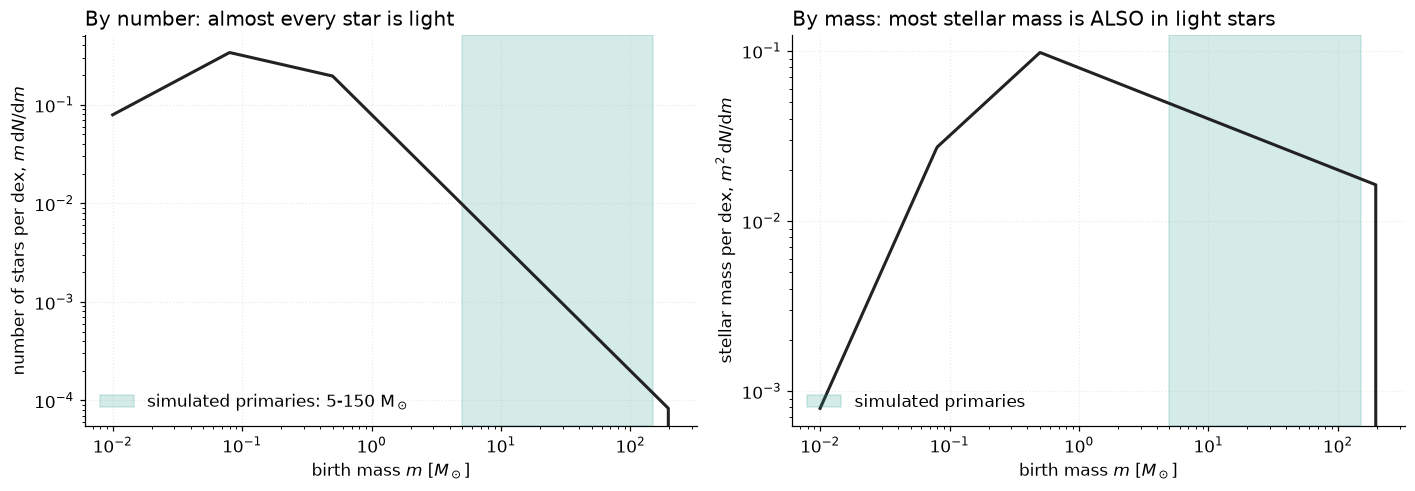

average mass of a star drawn from the IMF          : 0.389 Msun
fraction of stars (by number) born with 5-150 Msun : 0.75%   (1 in 134)
fraction of stellar MASS in stars of 5-150 Msun    : 26.9%


In [27]:
# --- Kroupa (2001) IMF: a three-part broken power law, dN/dm ∝ m^-alpha ----------------
IMF_BOUNDS = (0.01, 0.08, 0.5, 200.0)       # Msun: the mass bounds of the three segments
IMF_SLOPES = (0.3, 1.3, 2.3)                # alpha in each segment
M1_MIN, M1_MAX, M2_MIN, F_BIN = 5.0, 150.0, 0.1, 0.7   # the simulation's choices (van Son+22)


def kroupa_imf(m):
    '''dN/dm (unnormalised), continuous across the breaks.'''
    m = np.asarray(m, dtype=float)
    m0, m1, m2, m3 = IMF_BOUNDS
    a1, a2, a3 = IMF_SLOPES
    # continuity constants so the segments join up
    
    # At m1: m1**(-a1) == c2 * m1**(-a2), so c2 = m1**(a2 - a1).
    c2 = m1 ** (a2 - a1)

    # At m2: c2*m2**(-a2) == c3*m2**(-a3),
    # so c3 = c2*m2**(a3 - a2).
    c3 = c2 * m2 ** (a3 - a2)

    # Select the appropriate power law for each mass.
    # np.where(condition, value_if_true, value_if_false)
    out = np.where(m < m1, m ** -a1, np.where(m < m2, c2 * m ** -a2, c3 * m ** -a3))
    return np.where((m >= m0) & (m <= m3), out, 0.0)


# normalise so that the integral of dN/dm over all masses is 1  ->  a probability density
_norm = quad(kroupa_imf, IMF_BOUNDS[0], IMF_BOUNDS[-1], points=IMF_BOUNDS[1:-1])[0]
imf_pdf = lambda m: kroupa_imf(m) / _norm

m_grid = np.logspace(np.log10(IMF_BOUNDS[0]), np.log10(IMF_BOUNDS[-1]), 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# left: number of stars per dex of mass (m * dN/dm is what you see on a log axis)
axes[0].plot(m_grid, m_grid * imf_pdf(m_grid), color=CSYS, lw=2)
axes[0].axvspan(M1_MIN, M1_MAX, color=C_SMT, alpha=0.2, label=f"simulated primaries: {M1_MIN:.0f}-{M1_MAX:.0f} M$_\\odot$")
axes[0].set_ylabel(r"number of stars per dex, $m\,\mathrm{d}N/\mathrm{d}m$")
axes[0].set_title("By number: almost every star is light", loc="left")

# right: MASS per dex (m^2 dN/dm) -- this is what a star formation rate measures
axes[1].plot(m_grid, m_grid**2 * imf_pdf(m_grid), color=CSYS, lw=2)
axes[1].axvspan(M1_MIN, M1_MAX, color=C_SMT, alpha=0.2, label="simulated primaries")
axes[1].set_ylabel(r"stellar mass per dex, $m^2\,\mathrm{d}N/\mathrm{d}m$")
axes[1].set_title("By mass: most stellar mass is ALSO in light stars", loc="left")

for ax in axes:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"birth mass $m$ [$M_\odot$]")
    ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

# the numbers behind the picture
frac_number = quad(imf_pdf, M1_MIN, M1_MAX)[0]
mass_pdf = lambda m: m * imf_pdf(m)
m_avg = quad(mass_pdf, IMF_BOUNDS[0], IMF_BOUNDS[-1], points=IMF_BOUNDS[1:-1])[0]
frac_mass = quad(mass_pdf, M1_MIN, M1_MAX)[0] / m_avg
print(f"average mass of a star drawn from the IMF          : {m_avg:.3f} Msun")
print(f"fraction of stars (by number) born with 5-150 Msun : {100*frac_number:.2f}%   (1 in {1/frac_number:.0f})")
print(f"fraction of stellar MASS in stars of 5-150 Msun    : {100*frac_mass:.1f}%")

### 📖 What the numbers say

- Only about **one star in 130** is born massive enough to be a simulated primary, and those
  stars hold only **~27%** of all the mass that goes into stars. The other ~73% of star-forming
  mass is in stars that will *never* make a black hole;  but it is all counted in a star
  formation rate.
- The average star drawn from the IMF has a mass well below 1 $M_\odot$ (the value printed
  above). Remember this number; it appears in the formula below.

## 1.3 How much star-forming mass does one simulated binary represent?

Now we turn the shaded fraction into a single number: $M_{\rm rep}$, the mass of stars formed
**per simulated binary**. The *idea* is written up in Appendix B of
[van Son et al. (2020)](https://arxiv.org/abs/2004.05187) (eqs. B9–B11: the fraction $f_{\rm sim}$
of a synthetic galaxy's mass that the simulated parameter space covers, and
$M_{\rm SF} = M_{\rm sim}/f_{\rm sim}$), following Dominik et al. (2012) and Neijssel et al. (2019).
The closed-form expression everyone actually uses has, as far as we know, never been written out
in a paper — it lives in the COMPAS
[cosmic integration code](https://github.com/TeamCOMPAS/COMPAS/tree/dev/compas_python_utils/cosmic_integration)
(derivation by Ilya Mandel). So here it is, step by step:

1. **Draw one "system" from the IMF.** With probability $f_{\rm bin} = 0.7$ it is a binary, with
   probability $0.3$ it is a single star. The primary (or the single star) has average mass
   $\langle m \rangle$. If it is a binary, its companion has $q$ drawn flat between 0 and 1, so its
   average mass is $\tfrac{1}{2}\langle m \rangle$; a binary therefore averages $1.5\,\langle m\rangle$.

2. **Mass per binary, counting the singles too.** For every binary you draw, you draw on average
   $(1-f_{\rm bin})/f_{\rm bin}$ single stars. So the star-forming mass associated with one binary is
   $$
   \langle m \rangle \left( 1.5 + \frac{1 - f_{\rm bin}}{f_{\rm bin}} \right).
   $$

3. **Only a fraction $f_{\rm sim}$ of binaries is inside the simulated box.** A binary is simulated
   only if its primary is in $[5, 150]\,\mathrm{M}_\odot$ *and* its secondary is above
   $0.1\,\mathrm{M}_\odot$. For a flat mass-ratio distribution, the second condition holds with
   probability $1 - m_{2,\min}/m_1$, so
   $$
   f_{\rm sim} = \int_{5}^{150} \frac{\mathrm{d}N}{\mathrm{d}m_1}\left(1 - \frac{0.1}{m_1}\right)\mathrm{d}m_1 .
   $$

4. **Put it together.** For every simulated binary, $1/f_{\rm sim}$ binaries were "drawn", each
   bringing the mass from step 2:
   $$
   \boxed{\; M_{\rm rep} = \frac{\langle m \rangle}{f_{\rm sim}} \left( 1.5 + \frac{1 - f_{\rm bin}}{f_{\rm bin}} \right) \;}
   $$

Let's evaluate each step numerically. (COMPAS ships an analytic version of the same formula,
`analytical_star_forming_mass_per_binary_using_kroupa_imf`; we check against it at the end.)

In [28]:
# step 1 & 2: mass per binary drawn, singles included
mass_per_binary_drawn = m_avg * (1.5 + (1 - F_BIN) / F_BIN)

# step 3: fraction of drawn binaries that fall inside the simulated box
f_sim = quad(lambda m: imf_pdf(m) * (1 - M2_MIN / m), M1_MIN, M1_MAX)[0]

# step 4
M_REP = mass_per_binary_drawn / f_sim

print(f"<m>  average mass of an IMF star                          = {m_avg:8.3f} Msun")
print(f"mass per binary drawn, incl. companion and single stars  = {mass_per_binary_drawn:8.3f} Msun")
print(f"f_sim  fraction of drawn binaries inside the simulated box = {f_sim:8.5f}   (1 in {1/f_sim:.0f})")
print(f"M_rep  star-forming mass represented by ONE simulated binary = {M_REP:6.1f} Msun")

# --- cross-check against the analytic formula used in the COMPAS cosmic-integration code ------
def analytical_star_forming_mass_per_binary_using_kroupa_imf(m1_min, m1_max, m2_min, fbin=1.0,
                                                             imf_mass_bounds=(0.01, 0.08, 0.5, 200)):
    '''Ilya Mandel's closed-form derivation; copied verbatim from COMPAS/compas_python_utils.'''
    m1, m2, m3, m4 = imf_mass_bounds
    alpha = (-(m4**(-1.3) - m3**(-1.3))/1.3 - (m3**(-0.3) - m2**(-0.3))/(m3*0.3)
             + (m2**0.7 - m1**0.7)/(m2*m3*0.7))**(-1)
    m_avg = alpha * (-(m4**(-0.3) - m3**(-0.3))/0.3 + (m3**0.7 - m2**0.7)/(m3*0.7)
                     + (m2**1.7 - m1**1.7)/(m2*m3*1.7))
    fint = (-alpha/1.3 * (m1_max**(-1.3) - m1_min**(-1.3))
            + alpha * m2_min/2.3 * (m1_max**(-2.3) - m1_min**(-2.3)))
    return (1/fint) * m_avg * (1.5 + (1 - fbin)/fbin)

M_REP_analytic = analytical_star_forming_mass_per_binary_using_kroupa_imf(M1_MIN, M1_MAX, M2_MIN, F_BIN)
print(f"\nCOMPAS analytic formula gives                                = {M_REP_analytic:6.1f} Msun"
      f"   (agree to {100*abs(M_REP/M_REP_analytic-1):.3f}%)")

# the total star-forming mass the whole simulation stands for
M_SIM = n_binaries_simulated * M_REP
print(f"\nTotal star-forming mass represented by the simulation, M_sim = {M_SIM:.3e} Msun"
      f"  (= {n_binaries_simulated/1e6:.0f} million binaries x {M_REP:.1f} Msun)")

<m>  average mass of an IMF star                          =    0.389 Msun
mass per binary drawn, incl. companion and single stars  =    0.750 Msun
f_sim  fraction of drawn binaries inside the simulated box =  0.00737   (1 in 136)
M_rep  star-forming mass represented by ONE simulated binary =  101.7 Msun

COMPAS analytic formula gives                                =  101.7 Msun   (agree to 0.000%)

Total star-forming mass represented by the simulation, M_sim = 1.017e+09 Msun  (= 10 million binaries x 101.7 Msun)


### 📖 Read that again

One simulated binary in our simulation stands for **about a hundred solar masses** of star formation, even though
its own two stars weigh only ~20 $M_\odot$ on average. The other ~80 $M_\odot$ is the invisible
tail of light stars and single stars that formed alongside it. The whole 10-million-binary
simulation represents **one billion solar masses** of star formation — roughly what the
[Milky Way](https://en.wikipedia.org/wiki/Milky_Way) forms in half a billion years.

> ⚠️ **Where the uncertainty hides.** $M_{\rm rep}$ depends on choices nobody can verify well:
> the IMF at the low-mass end (where most of the mass is), the binary fraction, and the
> assumption that $q$ is flat. Different papers make different choices, and it could change every merger rate by tens of percent but especially the double compact object properties by a lot. Our field used to think it wouldnt be a big different (e.g. de Mink et al. 2013, Klencki+19) on the rate, but recently we have come to realize that the distribution of properties of the compact objects (e.g. masses) might be significantly impacted (de Sa 2024a,b). The GROWL catalog plans to explore this for the first time. 

## 1.4 The formation efficiency — and a subtlety about metallicity

With $M_{\rm sim}$ in hand, the *average* formation efficiency of merging binary black holes is
simply $\eta_{\rm BBH} = \sum w \,/\, M_{\rm sim}$. Let's compute it for all three kinds of double
compact object.

In [29]:
print(f"{'kind':32s} {'sum of weights':>15s} {'eta = per Msun formed':>24s} {'one per ... Msun':>18s}")
print("-" * 94)
for name, mask in [("binary black holes, all",       dco.is_BBH),
                   ("binary black holes, MERGING",   dco.is_BBH & (dco.merges == 1)),
                   ("black hole - neutron star, merging", dco.is_BHNS & (dco.merges == 1)),
                   ("binary neutron stars, merging", dco.is_BNS & (dco.merges == 1))]:
    sw = dco.w[mask].sum()
    print(f"{name:32s} {sw:15,.0f} {sw / M_SIM:24.2e} {M_SIM / sw:18,.0f}")

ETA_BBH_MEAN = bbh.w.sum() / M_SIM
print(f"\nAveraged over the simulated (flat-in-log) metallicities: {ETA_BBH_MEAN:.2e} merging BBHs per Msun,"
      f" i.e. one per {1/ETA_BBH_MEAN:,.0f} Msun of star formation.")

kind                              sum of weights    eta = per Msun formed   one per ... Msun
----------------------------------------------------------------------------------------------
binary black holes, all                  117,689                 1.16e-04              8,642
binary black holes, MERGING               14,911                 1.47e-05             68,213
black hole - neutron star, merging           2,918                 2.87e-06            348,532
binary neutron stars, merging              6,508                 6.40e-06            156,298

Averaged over the simulated (flat-in-log) metallicities: 1.47e-05 merging BBHs per Msun, i.e. one per 68,213 Msun of star formation.


So on average the simulation makes **about one merging binary black hole per ~70,000 $M_\odot$ of
star formation.** But that average hides the single most important dependence in this whole
subject: **metallicity**.

You saw in Notebook 2 (Part 6) that metal-poor stars make heavier black holes. They also make
*many more* merging binaries, because weaker winds keep the stars massive and the orbits tight.
The formation efficiency is therefore a steep function of $Z$, and since the Universe's
metallicity changes with cosmic time, we need $\eta(Z)$, not just $\eta$.

Computing $\eta(Z)$ sounds trivial — histogram the weights in metallicity bins and divide by the
mass formed in each bin — and it is, **provided you divide by the right mass**. Here is the
subtlety, and it is worth slowing down for because it is easy to get wrong by a large factor:

> **The mass "formed" in a metallicity bin is the mass the simulation *represents* in that bin,
> not $M_{\rm sim}$.**
>
> The authors spread their 10 million binaries flat in $\log Z$. A bin covering one tenth of the
> $\log Z$ range therefore contains one tenth of the binaries, and represents one tenth of
> $M_{\rm sim}$. If you divide the weights in that bin by all of $M_{\rm sim}$, you get an
> efficiency that is ten times too small — and, worse, it *changes when you change the number
> of bins*. A physical quantity cannot depend on how finely you histogram it.

Concretely, for a bin $j$ of width $\Delta\log Z_j$ inside a simulated range of total width
$\Delta\log Z_{\rm tot} = \log_{10}(0.03/10^{-4}) \approx 2.48$ dex:

$$
M_j \;=\; M_{\rm sim}\,\frac{\Delta \log Z_j}{\Delta \log Z_{\rm tot}},
\qquad\qquad
\eta_j \;=\; \frac{\sum_{i \in j} w_i}{M_j}.
$$

We first verify the premise — that the simulated metallicities really are flat in $\log Z$ — using
the metallicities of *all* 10 million systems we loaded in the setup cell.

This is important as by default our cosmic integration code assumes the metallicities are log-uniform distributed

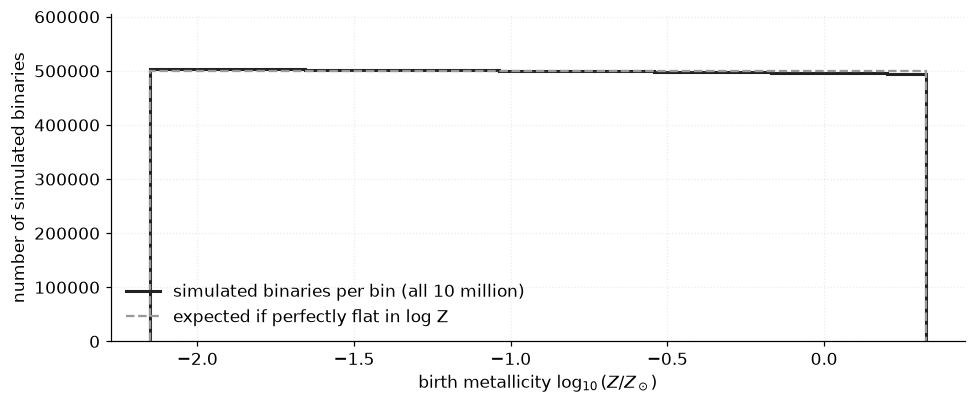

largest deviation from flat: 1.1%  (the adaptive sampler nudged the exploration slightly; a ~1% effect we ignore)


In [30]:
LOG_Z_MIN, LOG_Z_MAX = np.log10(Z_all_systems.min()), np.log10(Z_all_systems.max())
DLOGZ_TOT = LOG_Z_MAX - LOG_Z_MIN


def mass_formed_per_bin(log_z_edges):
    '''Star-forming mass represented by the simulation in each log10(Z) bin (flat-in-log sampling).'''
    return M_SIM * np.diff(log_z_edges) / DLOGZ_TOT


edges_check = np.linspace(LOG_Z_MIN, LOG_Z_MAX, 21)
n_per_bin, _ = np.histogram(np.log10(Z_all_systems), bins=edges_check)
expected = n_binaries_simulated * np.diff(edges_check) / DLOGZ_TOT

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.stairs(n_per_bin, edges_check - np.log10(Z_SUN), color=CSYS, lw=2, label="simulated binaries per bin (all 10 million)")
ax.stairs(expected, edges_check - np.log10(Z_SUN), color=C_WRONG, lw=1.5, ls="--", label="expected if perfectly flat in log Z")
ax.set_ylim(0, 1.2 * n_per_bin.max())
ax.set_xlabel(r"birth metallicity $\log_{10}(Z/Z_\odot)$")
ax.set_ylabel("number of simulated binaries")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

print(f"largest deviation from flat: {100*np.abs(n_per_bin/expected - 1).max():.1f}%  "
      "(the adaptive sampler nudged the exploration slightly; a ~1% effect we ignore)")

Flat to about 1%. Now below the plot that matters: $\eta(Z)$, done **correctly** (dividing by the mass
represented in each bin) — and, in grey, done **incorrectly** (dividing by $M_{\rm sim}$) with two
different bin counts, so you can see the trap with your own eyes.

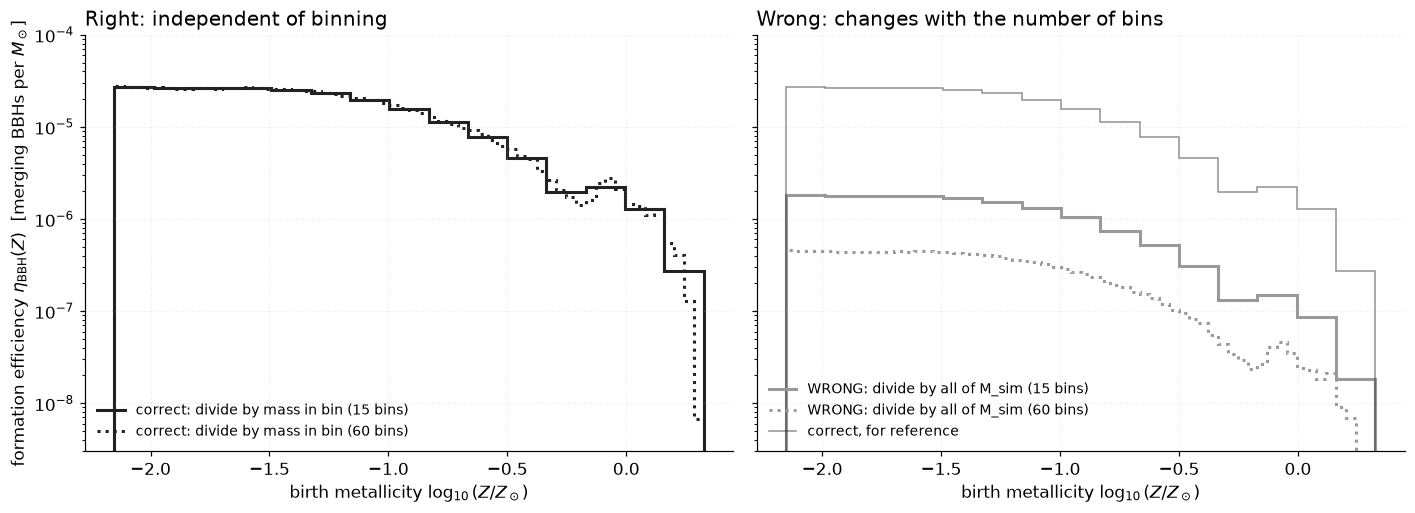

In [31]:
def formation_efficiency_vs_Z(sample, log_z_edges):
    '''eta_j = (sum of weights in bin j) / (mass formed in bin j)  [per Msun].'''
    sum_w, _ = np.histogram(np.log10(sample.Z), bins=log_z_edges, weights=sample.w)
    return sum_w / mass_formed_per_bin(log_z_edges)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

# --- left: the correct eta(Z), and it does not care how many bins you use --------------------
for nbins, ls in [(15, "-"), (60, ":")]:
    edges = np.linspace(LOG_Z_MIN, LOG_Z_MAX, nbins + 1)
    axes[0].stairs(formation_efficiency_vs_Z(bbh, edges), edges - np.log10(Z_SUN),
                   color=CSYS, lw=2, ls=ls, label=f"correct: divide by mass in bin ({nbins} bins)")
axes[0].set_title("Right: independent of binning", loc="left")

# --- right: the trap -- divide by the TOTAL simulated mass -----------------------------------
for nbins, ls in [(15, "-"), (60, ":")]:
    edges = np.linspace(LOG_Z_MIN, LOG_Z_MAX, nbins + 1)
    sum_w, _ = np.histogram(np.log10(bbh.Z), bins=edges, weights=bbh.w)
    axes[1].stairs(sum_w / M_SIM, edges - np.log10(Z_SUN), color=C_WRONG, lw=2, ls=ls,
                   label=f"WRONG: divide by all of M_sim ({nbins} bins)")
edges = np.linspace(LOG_Z_MIN, LOG_Z_MAX, 16)
axes[1].stairs(formation_efficiency_vs_Z(bbh, edges), edges - np.log10(Z_SUN), color=CSYS, lw=1, alpha=0.5, label="correct, for reference")
axes[1].set_title("Wrong: changes with the number of bins", loc="left")

for ax in axes:
    ax.set_yscale("log"); ax.set_ylim(3e-9, 1e-4)
    ax.set_xlabel(r"birth metallicity $\log_{10}(Z/Z_\odot)$")
    ax.legend(fontsize=9, loc="lower left")
axes[0].set_ylabel(r"formation efficiency $\eta_{\rm BBH}(Z)$  [merging BBHs per $M_\odot$]")
plt.tight_layout(); plt.show()

### 📖 Reading the correct curve

- **Metal-poor stars are efficient at making binary black holes.** Below $Z \approx 0.1\,Z_\odot$ the efficiency is a few
  $\times 10^{-5}$ per $M_\odot$: one merging binary black hole per ~30,000 $M_\odot$.
- **Around solar metallicity (log10(Z/Zsun) ~ 0) it drops** by more than an order of magnitude. Strong winds strip  the stars, the black holes come out less massive, and the orbits stay too wide to merge. This cliff is
  why the *metallicity history* of the Universe, not just its star formation history, decides the
  merger rate,  and why Part 2 spends so long on it.
- Behavior for binary black hole formation efficiency: that the efficiency is much higher at low metallicity, log10(Z/Zsun)<-1 compared to solar like metallicity log10(Z/Zsun), is something that has been consistently found in the literature. See E.g. Figure 1 in https://arxiv.org/abs/2411.02484 and Figure 1 of https://arxiv.org/pdf/2405.01623 ! We think this is because at low metallicity stellar winds (which are meatllicity driven for these massive stars) are not as strong, and due to several results from that it is easier to form a binary black hole system. Also note! Figures like the top left panel above are figures/results that end up in state-of-the-art publications in our field! In other words, you just made your first publishable figure! Congrats :):)
- The grey curves are a warning, not a result. They differ from each other by exactly the ratio of
  bin counts (4×), and from the truth by a factor equal to the number of bins. **If you ever feed
  a cosmic-integration code a per-system efficiency, check which mass it expects you to have
  divided by.** We will meet this again in Part 3.

## 1.5 A per-binary formation efficiency (what the next step needs)

Cosmic-integration codes usually want one number per simulated system: *how many merging
binaries per solar mass of star formation does this row stand for?* That is the same idea applied
to each row individually: each binary $i$ contributes $w_i$ merging systems out of the mass $M_j$
represented by its metallicity bin,

$$
\eta_i = \frac{w_i}{M_{j(i)}} .
$$

We store it in the `bbh` table as `eta`. Note that $\sum_i \eta_i\, (\Delta\log Z_j / \Delta\log Z_{\rm tot})$
reproduces the mean efficiency from §1.4 — a quick consistency check that the bookkeeping is right.

In [32]:
N_Z_BINS = 50                                  # fine enough to resolve eta(Z), coarse enough for good statistics
LOG_Z_EDGES = np.linspace(LOG_Z_MIN, LOG_Z_MAX, N_Z_BINS + 1)
mass_per_bin = mass_formed_per_bin(LOG_Z_EDGES)

bbh["z_bin"] = np.clip(np.digitize(np.log10(bbh.Z), LOG_Z_EDGES) - 1, 0, N_Z_BINS - 1)
bbh["eta"]   = bbh.w / mass_per_bin[bbh.z_bin.values]

# consistency check: the bin-weighted mean of eta_i must equal sum(w)/M_sim
frac_of_range = np.diff(LOG_Z_EDGES) / DLOGZ_TOT
eta_mean_from_rows = np.sum(bbh.groupby("z_bin").eta.sum().reindex(range(N_Z_BINS), fill_value=0).values * frac_of_range)
print(f"mean eta from the per-binary values : {eta_mean_from_rows:.4e} per Msun")
print(f"mean eta from sum(w)/M_sim  (§1.4)  : {ETA_BBH_MEAN:.4e} per Msun")
print(f"\nper-binary eta ranges from {bbh.eta.min():.1e} to {bbh.eta.max():.1e} per Msun (median {bbh.eta.median():.1e})")
bbh[["m1", "m2", "Z", "t_delay_Myr", "w", "eta"]].head()

mean eta from the per-binary values : 1.4660e-05 per Msun
mean eta from sum(w)/M_sim  (§1.4)  : 1.4660e-05 per Msun

per-binary eta ranges from 9.0e-11 to 1.9e-07 per Msun (median 3.0e-10)


,m1,m2,Z,t_delay_Myr,w,eta
1,14.970078,12.344720,0.000353,16.263755,0.003438,1.690009e-10
10,22.218283,8.174828,0.002052,224.994653,0.011389,5.598658e-10
21,16.235351,11.192523,0.000272,844.757920,0.003232,1.588587e-10
26,13.996301,8.319249,0.000154,213.249227,0.003387,1.665183e-10
43,16.613734,10.507898,0.000524,21.150669,0.004828,2.373258e-10


> ### ✍️ Task 1 — in your own words
>
> Before moving on, write **five to ten sentences** (in a text file, a notebook cell, wherever)
> answering:
>
> 1. What conceptually is a formation efficiency, and what are its units?
> 2. List every kind of stellar mass that is *counted in $M_{\rm rep}$* but *not simulated*.
>    (There are at least three.)
> 3. Why can the efficiency depend on metallicity, but must **not** depend on how many
>    metallicity bins you chose to plot the formation efficiency histogram above?
> 4. Which are some uncertainties that could impact the formation efficiency? (Think about tutorial 1: what are some of the physical processes that could impact what fraction of binary star systems could make a binary black hole? (ie how common a BBH outcome is for a binary star system)
>
> Bring your answers to the meeting. This is the single concept from this notebook that you will
> reuse most often — every GROWL catalogue entry needs it.

1. Formation efficiency, **$\eta$** measures how many merging DCOs form per unit of stellar mass represented by the simulation, so its units are $M_\odot^{-1}$.
2. The represented mass $M_{\rm rep}$ includes, stellar mass that COMPAS did not explicitly simulate, such as
    - stars in single systems,
    - stars in binaries whose primary masses fall outside the simulated range ($M < 5 M_{\odot}$),
    - and binary companions below the minimum simulated secondary mass ($M < 0.1 M_{\odot}$).
3. The efficiency can vary with metallicity because metallicity affects stellar winds and evolution, which in turn affect whether a binary forms a BBH. The number of metallicity bins is only a choice about how to group or display results; it does not change the simulated BBH count or the represented mass used to calculate the efficiency at a given metallicity.
4. Relevant uncertainties include stellar-wind strength, how much mass is transferred between stars, whether mass transfer is stable, and whether a binary survives a common-envelope phase. Supernova kicks and remnant formation also matter because they can disrupt a binary or change the masses of the resulting compact objects. Changes to these physical processes can therefore change what fraction of simulated binary systems produce a BBH.

<a id="part2"></a>
# Part 2 — Background: the ingredients of cosmic integration

> ✏️ *This part is written as reading material. There is no single paper that explains cosmic
> integration from scratch, so we have collected the pieces here. If you prefer to read the
> originals first, an optional reading list is in §2.6. Do not get too stuck in this section, its very normal that you dont understand all the equations; we will go over them in our meetings and on discord.*

## 2.1 The equation, once more, with feeling

$$
\mathcal{R}(z_{\rm merge}) = \int_0^{t_{\rm max}} \mathrm{d}t_{\rm delay}
\int_{Z_{\min}}^{Z_{\max}} \mathrm{d}Z \;
\underbrace{\psi\big(z_{\rm birth}\big)}_{\text{(A) how much star formation}}
\;\underbrace{\frac{\mathrm{d}P}{\mathrm{d}Z}\big(Z \,\big|\, z_{\rm birth}\big)}_{\text{(B) at which metallicity}}
\;\underbrace{\eta(Z, t_{\rm delay})}_{\text{(C) Part 1, per delay time}}
\qquad\text{with}\quad
z_{\rm birth} = z_{\rm birth}(z_{\rm merge}, t_{\rm delay}) \;\;\text{(D)}.
$$

Read it right to left. Pick a merger redshift. Pick a delay time; that fixes the birth redshift
(D). At that birth redshift, look up how much star formation there was (A) and how it was split
over metallicities (B). Multiply by how many merging binaries a unit of star formation at that
metallicity produces *with that delay time* (C). Sum over all delay times and all metallicities.

The product (A)×(B) is the **metallicity-specific star formation rate density**
$S(Z, z) = \psi(z)\,\mathrm{d}P/\mathrm{d}Z(Z|z)$. Everything about the Universe is in $S(Z,z)$;
everything about binary physics is in $\eta$. That separation is what makes the approach
powerful: you can swap either half independently, and papers do exactly that
([van Son et al. 2023](https://arxiv.org/abs/2209.03385) vary $S(Z,z)$; Notebook 2's channels
paper varies the physics in $\eta$).

## 2.2 (A) The cosmic star formation history $\psi(z)$

**What it is.** The mass of stars formed per year, per comoving Mpc³, averaged over the whole
Universe, as a function of redshift. Its shape is one of the best-established results in
extragalactic astronomy: star formation rose from the first galaxies, peaked around $z \approx 2$
("cosmic noon", ~10 billion years ago), and has declined by about a factor of ten since. The
Universe is well past its star-forming prime.

**How it is measured** — this is worth knowing, because the systematic uncertainties come from
here:

- **Ultraviolet light** from young, massive stars. Massive stars live only a few Myr, so UV
  luminosity traces *current* star formation. Surveys measure the UV luminosity of many galaxies at
  each redshift (a "luminosity function"), integrate, and convert luminosity to mass formed per
  year — which requires an **IMF** (Part 1 again: the conversion assumes how many low-mass stars
  form per massive one).
- **Infrared light** from dust that absorbed the UV and re-radiated it. About half of all star
  formation at cosmic noon is dust-obscured; miss it and you underestimate $\psi$ by 2×.
- **Emission lines** ($H \alpha$, [O II]) from gas ionised by the same massive stars.
- At the highest redshifts ($z \gtrsim 6$) the census is being rewritten by
  [JWST](https://en.wikipedia.org/wiki/James_Webb_Space_Telescope) as we speak.

The standard reference is the review by
[Madau & Dickinson (2014)](https://arxiv.org/abs/1403.0007), who fitted the compilation with
$$
\psi(z) = a\,\frac{(1+z)^b}{1 + \left[(1+z)/c\right]^d}\qquad [\mathrm{M}_\odot\,\mathrm{yr}^{-1}\,\mathrm{Mpc}^{-3}].
$$
We use the same functional form with the parameters that
[van Son et al. (2023)](https://arxiv.org/abs/2209.03385) fitted to the
[TNG100](https://www.tng-project.org/) cosmological simulation ($a = 0.02,\ b = 1.48,\ c = 4.45,\ d = 5.9$),
because those are the parameters behind the authors' own rates in the data file — which lets us
check our answer against theirs in Part 4.

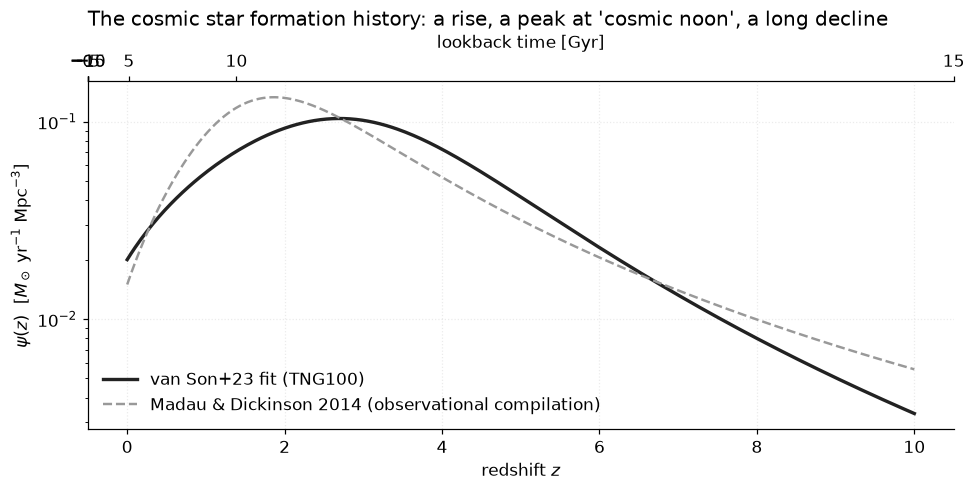

this fit peaks at z = 2.71 (11.4 Gyr ago; the observational fit peaks nearer z = 2); today's rate is 0.19x the peak
psi(z=0) = 0.0200 Msun/yr/Mpc^3 = 2.0e+07 Msun/yr/Gpc^3


In [33]:
def sfr_density(z, a=0.02, b=1.48, c=4.45, d=5.9):
    '''Madau & Dickinson (2014) functional form; default parameters from van Son et al. (2023).
    Returns Msun / yr / Mpc^3 (comoving).'''
    return a * (1 + z) ** b / (1 + ((1 + z) / c) ** d)


z_grid = np.linspace(0, 10, 400)
psi = sfr_density(z_grid)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(z_grid, psi, color=CSYS, lw=2.2, label="van Son+23 fit (TNG100)")
ax.plot(z_grid, sfr_density(z_grid, 0.015, 2.7, 2.9, 5.6), color=C_WRONG, lw=1.6, ls="--",
        label="Madau & Dickinson 2014 (observational compilation)")
ax.set_yscale("log")
ax.set_xlabel("redshift $z$")
ax.set_ylabel(r"$\psi(z)$  [$M_\odot$ yr$^{-1}$ Mpc$^{-3}$]")
ax.set_title("The cosmic star formation history: a rise, a peak at 'cosmic noon', a long decline", loc="left")
ax.legend(loc="lower left")

# a second axis in lookback time, so you can read 'how long ago' directly
secax = ax.secondary_xaxis("top", functions=(lambda z: cosmo.lookback_time(z).value,
                                             lambda t: np.interp(t, cosmo.lookback_time(z_grid).value, z_grid)))
secax.set_xlabel("lookback time [Gyr]")
plt.tight_layout(); plt.show()

z_peak = z_grid[np.argmax(psi)]
print(f"this fit peaks at z = {z_peak:.2f} ({cosmo.lookback_time(z_peak).value:.1f} Gyr ago; the observational fit peaks nearer z = 2); "
      f"today's rate is {psi[0]/psi.max():.2f}x the peak")
print(f"psi(z=0) = {psi[0]:.4f} Msun/yr/Mpc^3 = {psi[0]*1e9:.1e} Msun/yr/Gpc^3")

> 💡 **Two curves, two philosophies.** The dashed line is a fit to *observations*; the solid line
> is a fit to a *cosmological simulation*. They agree to within the observational scatter at
> $z \lesssim 3$ and disagree at high redshift, where the data are sparse. Neither is "the truth";
> the difference between them is a fair estimate of the systematic uncertainty on $\psi$, and it
> propagates directly into the merger rate at high $z$.

## 2.3 (B) The metallicity distribution $\mathrm{d}P/\mathrm{d}Z(Z \mid z)$

**What it is.** At a given redshift, the fraction of newly formed stellar mass that is born with
each metallicity. It is a *distribution* at every redshift, not a single number: at any epoch, big
galaxies are metal-rich and dwarf galaxies are metal-poor, and star formation happens in both.

**Why it dominates everything.** Recall the cliff in $\eta(Z)$ at solar metallicity (§1.4). The
merger rate is set almost entirely by *how much low-metallicity star formation there is at each
redshift* — and that is the least well-known part of $S(Z,z)$. The total $\psi(z)$ is known to
~30%; the low-metallicity tail of $\mathrm{d}P/\mathrm{d}Z$ is uncertain by factors of several.
[Chruślińska (2024)](https://arxiv.org/abs/2206.10622) is the review to read on this.

**How it is measured**, indirectly, by chaining three empirical relations:

1. the **galaxy stellar mass function** (how many galaxies of each mass exist at each $z$),
2. the **star-forming main sequence** (how fast a galaxy of a given mass forms stars), and
3. the **mass–metallicity relation** (how metal-rich the gas in a galaxy of a given mass is,
   measured from the strength of emission lines like [O III] and [N II] in its spectrum).

Multiply them together and you get "how much star formation happens at each metallicity". Every
link in that chain has its own systematics — the mass–metallicity relation alone shifts by
0.3–0.7 dex depending on how one calibrates the line ratios — which is why the answer is so
uncertain.

**The model we use.** [Neijssel et al. (2019)](https://arxiv.org/abs/1906.08136) proposed, and
[van Son et al. (2023)](https://arxiv.org/abs/2209.03385) refined, a compact parametrisation: at
each redshift $\ln Z$ follows a **skewed log-normal distribution** whose mean metallicity
decreases with redshift as $\langle Z \rangle = \mu_0\,10^{\mu_z z}$, with width $\sigma_0 10^{\sigma_z z}$
and a skewness $\alpha$ that puts extra weight on the metal-poor tail. The five parameters
($\mu_0 = 0.025,\ \mu_z = -0.05,\ \sigma_0 = 1.125,\ \sigma_z = 0.05,\ \alpha = -1.77$) are —
again — the ones in the name of the `Rates_...` group of our data file.

The implementation below is deliberately transparent (a dozen lines). SSPC ships the same function
as `metallicity_distribution_vanSon2022`; we will use that in Part 3, and check here that they
agree.

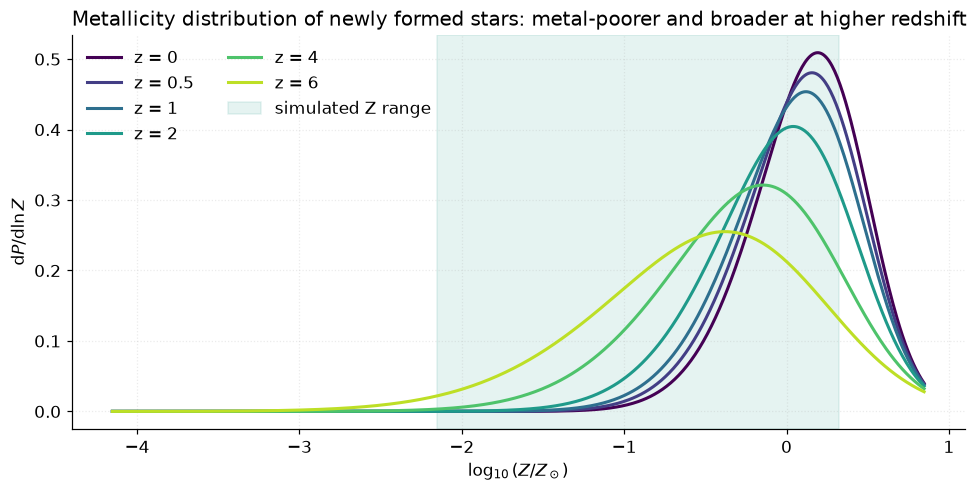

fraction of star formation at Z < 0.1 Zsun:
   z = 0:   0.3%
   z = 0.5:   0.5%
   z = 1:   1.0%
   z = 2:   2.6%
   z = 4:  10.0%
   z = 6:  23.8%

fraction of z = 0 star formation inside the plotted range 1e-6 < Z < 0.1: 0.991  (the rest is above Z = 0.1)


In [34]:
from scipy.stats import norm as NormDist


def dP_dlnZ(lnZ, z, mu0=0.025, muz=-0.05, sigma0=1.125, sigmaz=0.05, alpha=-1.77):
    '''Skewed log-normal metallicity distribution of van Son et al. (2023), section 2.
    Returns dP/dlnZ at natural-log metallicities `lnZ` (1D) for redshifts `z` (1D): shape (len(z), len(lnZ)).
    Normalised so that the integral over lnZ from -inf to +inf is 1 at every redshift.'''
    z = np.atleast_1d(z)[:, None]; lnZ = np.atleast_1d(lnZ)[None, :]
    sigma = sigma0 * 10 ** (sigmaz * z)                         # width grows slowly with z
    mean_Z = mu0 * 10 ** (muz * z)                              # mean metallicity falls with z
    beta = alpha / np.sqrt(1 + alpha**2)
    # location parameter mu such that the distribution has mean <Z> = mean_Z
    mu = np.log(mean_Z / 2 / (np.exp(0.5 * sigma**2) * NormDist.cdf(beta * sigma)))
    x = (lnZ - mu) / sigma
    return 2 / sigma * NormDist.pdf(x) * NormDist.cdf(alpha * x)


lnZ_grid = np.linspace(np.log(1e-6), np.log(0.1), 600)
z_show = np.array([0, 0.5, 1, 2, 4, 6])
P = dP_dlnZ(lnZ_grid, z_show)

fig, ax = plt.subplots(figsize=(9, 4.6))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(z_show)))
for k, zz in enumerate(z_show):
    ax.plot(np.log10(np.exp(lnZ_grid) / Z_SUN), P[k], color=colors[k], lw=2, label=f"z = {zz:g}")
ax.axvspan(LOG_Z_MIN - np.log10(Z_SUN), LOG_Z_MAX - np.log10(Z_SUN), color=C_SMT, alpha=0.12, label="simulated Z range")
ax.set_xlabel(r"$\log_{10}(Z/Z_\odot)$")
ax.set_ylabel(r"$\mathrm{d}P/\mathrm{d}\ln Z$")
ax.set_title("Metallicity distribution of newly formed stars: metal-poorer and broader at higher redshift", loc="left")
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

# how much star formation happens BELOW 0.1 Zsun at each redshift?  (this is what makes BBHs)
dlnZ = lnZ_grid[1] - lnZ_grid[0]
low_Z = np.exp(lnZ_grid) < 0.1 * Z_SUN
print("fraction of star formation at Z < 0.1 Zsun:")
for k, zz in enumerate(z_show):
    print(f"   z = {zz:g}: {100 * P[k][low_Z].sum() * dlnZ:5.1f}%")
print(f"\nfraction of z = 0 star formation inside the plotted range 1e-6 < Z < 0.1: {P[0].sum() * dlnZ:.3f}  (the rest is above Z = 0.1)")

> 💡 **Look at the shaded band**. At every redshift a sizeable slice of star formation happens outside the simulated metallicity range — above $Z=0.03$
 at low redshift $z$ (almost 30% of today's star formation, in this model), below $Z=10^-4$ at high $z$. A cosmic-integration code has to decide what to do with that mass. The usual choice (and ours) is to *drop* it: stars above $Z=0.03$ make essentially no merging black holes (recall the cliff in $\eta(Z)$
), and stars below $Z=10^-4$  are rare. But it is a choice, and it is one of the reasons two codes fed the same simulation can disagree by a few percent. This might actually be something we might have to fix (ie. that could be a fun project) but for now we will leave it as is (it will be relatively a small contribution). Let me know if you want to take this on, it can be a really fun project thinking about cosmic star formatiom!

Putting (A) and (B) together gives $S(Z, z)$: a 2D map of how much stellar mass formed at each
metallicity and redshift. This map is the "Universe" half of the calculation.

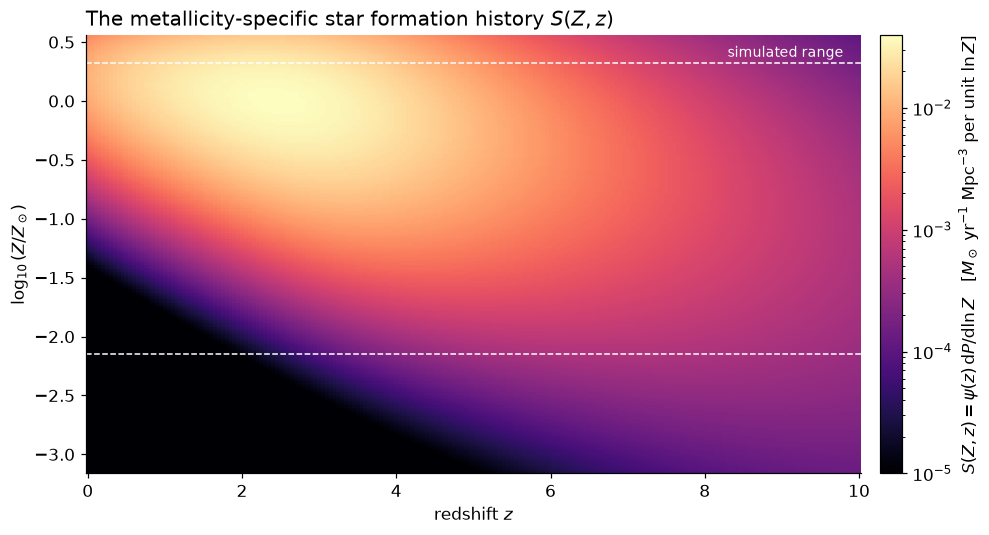

In [35]:
z_map = np.linspace(0, 10, 201)
lnZ_map = np.linspace(np.log(1e-5), np.log(0.05), 200)
S = sfr_density(z_map)[:, None] * dP_dlnZ(lnZ_map, z_map)      # Msun/yr/Mpc^3 per unit lnZ

fig, ax = plt.subplots(figsize=(9.5, 5))
pcm = ax.pcolormesh(z_map, np.log10(np.exp(lnZ_map) / Z_SUN), S.T, cmap="magma",
                    norm=plt.matplotlib.colors.LogNorm(vmin=1e-5, vmax=S.max()), shading="auto", rasterized=True)
cb = fig.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label(r"$S(Z,z) = \psi(z)\,\mathrm{d}P/\mathrm{d}\ln Z$   [$M_\odot$ yr$^{-1}$ Mpc$^{-3}$ per unit $\ln Z$]")
ax.axhline(LOG_Z_MIN - np.log10(Z_SUN), color="w", ls="--", lw=1)
ax.axhline(LOG_Z_MAX - np.log10(Z_SUN), color="w", ls="--", lw=1)
ax.text(9.8, LOG_Z_MAX - np.log10(Z_SUN) + 0.05, "simulated range", color="w", ha="right", fontsize=9)
ax.set_xlabel("redshift $z$"); ax.set_ylabel(r"$\log_{10}(Z/Z_\odot)$")
ax.set_title("The metallicity-specific star formation history $S(Z,z)$", loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

## 2.4 (D) Delay times: turning "merges at $z$" into "was born at $z'$"

The last ingredient is bookkeeping with a cosmological clock. Redshift is a proxy for time: the
[lookback time](https://en.wikipedia.org/wiki/Cosmic_time) $t_{\rm lb}(z)$ is how long ago light from
redshift $z$ set out, and for our purposes how long ago a binary "at redshift $z$" existed. A binary
that **merges** at $z_{\rm merge}$ after a delay $t_{\rm delay}$ was **born** at the redshift whose
lookback time is

$$
t_{\rm lb}(z_{\rm birth}) = t_{\rm lb}(z_{\rm merge}) + t_{\rm delay}.
$$

The conversion $z \leftrightarrow t_{\rm lb}$ needs a cosmology (`astropy` does it). Two features
matter for us:

- **The clock runs fast at high redshift.** Between $z=0$ and $z=1$ is 8 Gyr; between $z=1$ and
  $z=2$ only 2.5 Gyr; $z = 6$ to $z = 10$ is under half a Gyr. A delay of 1 Gyr is nothing for a
  merger at $z=0.2$, but it pushes a merger at $z=4$ back to $z \approx 8$.
- **Long delays reach back before star formation began.** A merger at $z = 0.2$ with a delay of
  13 Gyr would have been born before the first stars. Those systems contribute nothing — which is
  the same thing as the `Merges_Hubble_Time` cut from Notebook 2, made precise.

Recall from Notebook 2 (Exercise 2) that delay times span a huge range and roughly follow
$\mathrm{d}N/\mathrm{d}t \propto t^{-1}$. So *most* merging binaries merge soon after birth, but a
long tail merges billions of years later; today's merger rate is a mixture of recently formed
binaries and relics of cosmic noon. Let's see both facts at once.

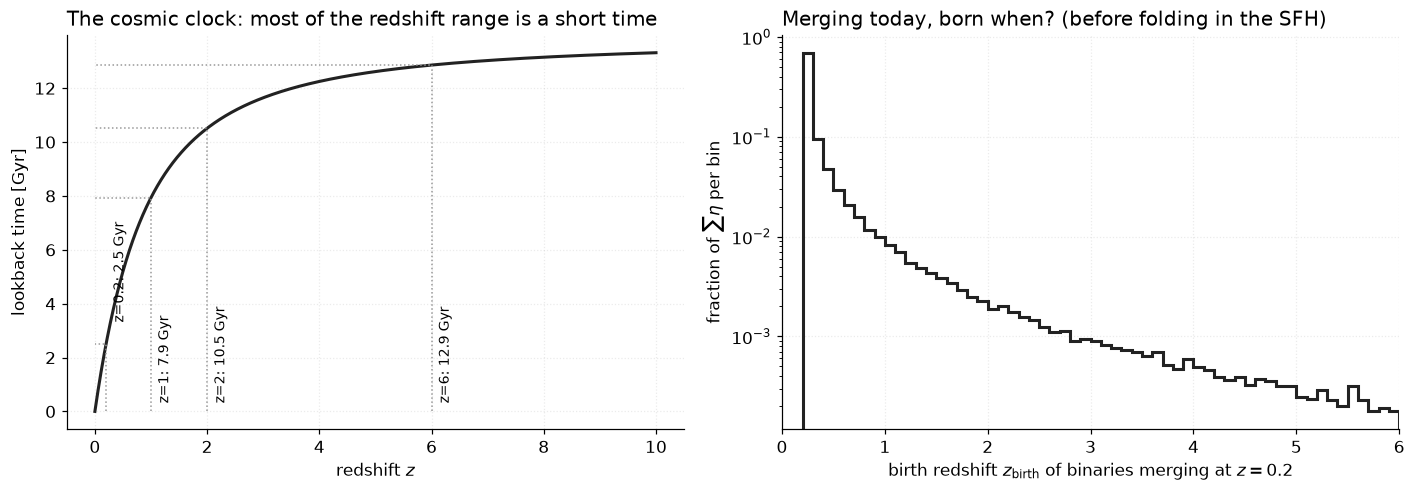

of the merging BBHs, 1.7% (unweighted rows) have delay times so long that, merging at z = 0.2, they would have been born before z = 10 -> they drop out
eta-weighted fraction of z = 0.2 mergers born at z_birth > 1 (i.e. > 8 Gyr ago): 7.6%  -- before any star formation history is applied
eta-weighted median delay time: 338 Myr — see Notebook 2, Exercise 2 for the full distribution


In [36]:
# lookback time <-> redshift, once, on a grid (much faster than astropy's z_at_value in a loop)
Z_GRID = np.linspace(0, 20, 4001)
T_LB_GRID_MYR = cosmo.lookback_time(Z_GRID).to(u.Myr).value
T_LB_FIRST_STARS_MYR = cosmo.lookback_time(10).to(u.Myr).value     # we start star formation at z = 10


def lookback_time_Myr(z):
    return np.interp(z, Z_GRID, T_LB_GRID_MYR)


def redshift_at_lookback_time(t_lb_Myr):
    '''Inverse of the above. Returns nan for times before z = 20.'''
    return np.interp(t_lb_Myr, T_LB_GRID_MYR, Z_GRID, right=np.nan)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# left: the cosmic clock
axes[0].plot(Z_GRID[Z_GRID <= 10], T_LB_GRID_MYR[Z_GRID <= 10] / 1e3, color=CSYS, lw=2)
for zz in [0.2, 1, 2, 6]:
    axes[0].plot([zz, zz, 0], [0, lookback_time_Myr(zz)/1e3, lookback_time_Myr(zz)/1e3], color=C_WRONG, lw=1, ls=":")
    axes[0].text(zz + 0.12, 0.3 + (3.0 if zz == 0.2 else 0), f"z={zz:g}: {lookback_time_Myr(zz)/1e3:.1f} Gyr", fontsize=9, rotation=90, va="bottom")
axes[0].set_xlabel("redshift $z$"); axes[0].set_ylabel("lookback time [Gyr]")
axes[0].set_title("The cosmic clock: most of the redshift range is a short time", loc="left")

# right: where were today's (z = 0.2) merging BBHs born?  weighted by eta, so it's a real distribution
z_merge = 0.2
t_birth = lookback_time_Myr(z_merge) + bbh.t_delay_Myr.values
z_birth = redshift_at_lookback_time(t_birth)
born_after_first_stars = t_birth < T_LB_FIRST_STARS_MYR
eta_ok = bbh.eta.values[born_after_first_stars]
axes[1].hist(z_birth[born_after_first_stars], bins=np.linspace(0, 6, 61), weights=eta_ok / eta_ok.sum(),
             histtype="step", lw=2, color=CSYS)
axes[1].set_yscale("log"); axes[1].set_xlim(0, 6)
axes[1].set_xlabel(r"birth redshift $z_{\rm birth}$ of binaries merging at $z = 0.2$")
axes[1].set_ylabel(r"fraction of $\sum \eta$ per bin")
axes[1].set_title("Merging today, born when? (before folding in the SFH)", loc="left")
plt.tight_layout(); plt.show()

print(f"of the merging BBHs, {100*np.mean(~born_after_first_stars):.1f}% (unweighted rows) have delay times so long that,"
      f" merging at z = {z_merge}, they would have been born before z = 10 -> they drop out")
print(f"eta-weighted fraction of z = {z_merge} mergers born at z_birth > 1 (i.e. > {lookback_time_Myr(1)/1e3:.0f} Gyr ago): "
      f"{100*eta_ok[z_birth[born_after_first_stars] > 1].sum()/eta_ok.sum():.1f}%  -- before any star formation history is applied")
order = np.argsort(bbh.t_delay_Myr.values)
cum = np.cumsum(bbh.eta.values[order]); t_med = bbh.t_delay_Myr.values[order][np.searchsorted(cum, 0.5 * cum[-1])]
print(f"eta-weighted median delay time: {t_med:,.0f} Myr — see Notebook 2, Exercise 2 for the full distribution")

> ⚠️ **The right-hand plot is not yet a prediction** — it ignores that far more stars formed at
> $z \approx 2$ than at $z \approx 0.2$, and that they formed at lower metallicity. It shows only
> the *delay-time* part of the story: even without any star formation history, a non-negligible
> tail (~8% by efficiency) of the binaries merging today were born at $z > 1$, more than 8 Gyr ago. Once $S(Z,z)$ is folded in
> (Part 3), the high-redshift births get boosted further, both because there was more star
> formation and because it was metal-poorer.

## 2.5 What "the integration" actually does, numerically

Nobody evaluates the double integral of §2.1 analytically. In practice, for each simulated binary
$i$ and each merger-redshift bin:

1. compute its birth lookback time $t_{\rm lb}(z_{\rm merge}) + t_{{\rm delay},i}$ and hence
   $z_{{\rm birth},i}$ (§2.4);
2. look up $S(Z_i, z_{{\rm birth},i})$ — or rather, the mass formed in binary $i$'s metallicity bin
   at that redshift, $\psi(z_{\rm birth})\,\Delta P_j$ (§2.2–2.3);
3. multiply by the binary's per-system efficiency $\eta_i$ (§1.5);
4. **sum over all binaries** in the merger-redshift bin.

Step 4 is the integral; the simulated binaries *are* the sample points. Because each binary keeps
its identity, you can also histogram the summed contributions by $m_1$, or by channel, or by
anything else in the table — that is how the mass distribution at $z = 0.2$ in Part 4 will be made.
This is exactly what SSPC does, and Part 3 walks through its inputs one at a time.

## 2.6 Optional Reading list, and a task

There is no single "cosmic integration for beginners" paper. These are the pieces, in a sensible
order; skim the first two, dip into the others as needed. OK to skip / pick one (its very easy to get stuck here with reading very technical papers/derivations - in that case just skip it and ask us to explain cosmic integration conceptionally) 

| | What to read | Why |
|---|---|---|
| 📄 | [Neijssel et al. (2019)](https://arxiv.org/abs/1906.08136), **§2–3** | The COMPAS cosmic-integration method, written out step by step. The closest thing to a methods paper. |
| 📄 | [van Son et al. (2023)](https://arxiv.org/abs/2209.03385), **§2 and Fig. 1** | The $S(Z,z)$ we use, where its parameters come from, and how much the BBH mass distribution cares. Short and clear. |
| 📄 | [Madau & Dickinson (2014)](https://arxiv.org/abs/1403.0007), **§1–3 and §5** | *The* review of the cosmic star formation history and how it is measured. Long; read the figures. |
| 📄 | [Chruślińska (2024)](https://arxiv.org/abs/2206.10622) | Review of the metallicity-specific SFH and why it is the dominant uncertainty for gravitational-wave rates. |
| 📄 | [COMPAS method paper (2022),](https://arxiv.org/pdf/2109.10352), **§3** | Description and derivation of cosmic integration. |
| 📄 | [van Son et al. (2020)](https://arxiv.org/abs/2004.05187), **Appendix B** | The formation-yield bookkeeping of §1.3 ($f_{\rm sim}$, $M_{\rm SF}$, and the STROOPWAFEL weights), as close to a written-up version as exists. |
| 💻 | [SSPC documentation](https://synthetic-stellar-pop-convolve.readthedocs.io/en/latest/) | The code we use in Part 3 — in particular the "GW merger rate density" example notebook. |

> ### ✍️ Task 2 — the star formation history in your own words
>
> After reading (at least the figures of) Madau & Dickinson and van Son et al. 2023 §2, write a
> short paragraph on each:
>
> 1. **In your own words, conceptionally what is the cosmic star formation rate $\psi(z)$?** 
> 2.**What ingredients go into the cosmic star formation history $\psi(z)$**, and how might we
>    *observe* some of them? Which of those observations depends on an IMF, and why does that
>    matter for us specifically?
> 3. **In your own words, conceptionally what is the metallicity dependent cosmic star formation history $S(Z,z)$?** Why does it depend on $Z$ and $z$? 
> 4. **(Extra:) What ingredients go into the metallicity distribution $\mathrm{d}P/\mathrm{d}Z(Z|z)$**,
>    and which one would you guess is the least certain?
> 5. (Extra:) If you could ask JWST for one measurement to reduce the uncertainty on the binary black hole
>    merger rate at $z = 2$, what would it be?

<a id="part3"></a>
# Part 3 — Running the cosmic integration with SSPC

## 3.1 What SSPC is, and how to install it (please ping us if you run into installation issues; this part of the tutorial is brand new and not tested well!) 

[**SSPC**](https://synthetic-stellar-pop-convolve.readthedocs.io/en/latest/) — *Synthetic Stellar
Population Convolve* — is a Python package by David Hendriks that does exactly the sum of §2.5,
for any population synthesis output, with any $S(Z,z)$ you give it. The original is on
[GitLab](https://gitlab.com/dhendriks/syntheticstellarpopconvolve) and is no longer actively
maintained, so GROWL keeps its own copy with fixes at
**https://github.com/FloorBroekgaarden/growl-syntheticstellarpopconvolve** (GPL-3, with full
credit to the original — if you use it, cite the SSPC documentation *and* say which fork).

Install it once, into the same Python you run this notebook with:

```bash
pip install git+https://github.com/FloorBroekgaarden/growl-syntheticstellarpopconvolve
```

It needs `astropy`, `h5py`, `pandas` and **`tables`** (PyTables, for writing pandas tables into
HDF5) — `pip install tables` if the import below complains about it.

> 🛠️ **If you have a local clone instead** (e.g. you are editing the code), set `SSPC_PATH`
> below to its folder and the cell will import from there.

In [37]:
#pip install git+https://github.com/FloorBroekgaarden/growl-syntheticstellarpopconvolve

In [38]:
import sys, os, copy, logging, time

SSPC_PATH = "/Users/floorbroekgaarden/Projects/GitHub/syntheticstellarpopconvolve"   # only used if the pip install is absent

try:
    import syntheticstellarpopconvolve
except ImportError:
    sys.path.insert(0, SSPC_PATH)
    import syntheticstellarpopconvolve

from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, print_hdf5_structure
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022

print("SSPC version", syntheticstellarpopconvolve.__version__, "imported from", os.path.dirname(syntheticstellarpopconvolve.__file__))

SSPC version 0.4 imported from c:\Users\marya\AppData\Local\Programs\Python\Python314\Lib\site-packages\syntheticstellarpopconvolve


## 3.2 What SSPC needs from us — and the one thing to get right

SSPC takes three things:

| Input | What it is | Where we get it |
|---|---|---|
| **The input table** | One row per simulated system: its `delay_time`, its `metallicity`, and its **`normalized_yield`** — how many events per solar mass of star formation the row stands for. Stored in an HDF5 file. | `bbh` from Part 1: `t_delay_Myr`, `Z`, and **`eta`** |
| **The SFR dictionary** | $S(Z,z)$ on a grid: redshift bin edges, $\psi(z)$ per bin, metallicity bin edges, and $\mathrm{d}P/\mathrm{d}Z$ per (redshift, metallicity) bin. | Part 2's `sfr_density` and `dP_dlnZ` |
| **The configuration** | Which redshifts to evaluate the rate at, which cosmology, where to write output. | below |

Internally, for each system $i$ and each merger redshift, SSPC computes

$$
\text{rate}_i \;=\; \texttt{normalized\_yield}_i \;\times\; \psi(z_{{\rm birth},i}) \;\times\;
\underbrace{\frac{\mathrm{d}P}{\mathrm{d}Z}\Big|_{j(i)}\,\Delta Z_{j(i)}}_{\text{fraction of star formation in system } i\text{'s metallicity bin}}
$$

and then sums. Read the last factor carefully: SSPC multiplies by the **fraction of all star
formation that lands in the metallicity bin of system $i$**. So `normalized_yield` must be the
number of events **per solar mass formed *in that bin*** — which is exactly what `eta` from §1.5
is ($w_i / M_j$). This is the §1.4 trap in its natural habitat: hand SSPC $w_i/M_{\rm sim}$ instead,
and every rate comes out low by a factor equal to your number of metallicity bins, with no error
message. (Exercise 6 lets you make this mistake on purpose.)

> ⚠️ Also: the metallicity bins you give SSPC in the SFR dictionary must be the **same bins** you
> used to compute `eta`. We stored those as `LOG_Z_EDGES` in §1.5 and reuse them below.

## 3.3 The input file

SSPC works from a single HDF5 file: it reads the input table from `input_data/<name>` and later
writes its results into `output_data/<name>/...` in the same file. We create the file with
SSPC's boilerplate helper, then drop our table in with pandas. Only the three columns SSPC needs
go in; everything else (`m1`, `m2`, `n_CE`, ...) stays in our `bbh` table, **in the same row
order**, which is how we will attach masses to the results later.

In [39]:
SSPC_DIR = "data/sspc"                     # output goes here (ignored by git -- it is a few hundred MB)
os.makedirs(os.path.join(SSPC_DIR, "tmp"), exist_ok=True)
SSPC_FILE = os.path.join(SSPC_DIR, "vanSon22_BBH_cosmic_integration.h5")

if os.path.exists(SSPC_FILE):
    os.remove(SSPC_FILE)                   # start clean; SSPC appends to existing files
generate_boilerplate_outputfile(SSPC_FILE)

sspc_input = pd.DataFrame({
    "delay_time":  bbh.t_delay_Myr.values,      # Myr -- we tell SSPC the unit in the config
    "metallicity": bbh.Z.values,
    "eta":         bbh.eta.values,              # merging BBHs per Msun formed in this system's Z bin
})
sspc_input.to_hdf(SSPC_FILE, key="input_data/bbh")

with h5py.File(SSPC_FILE, "r") as f:
    print_hdf5_structure(f)
print(f"\n{len(sspc_input):,} rows written to {SSPC_FILE}  ({os.path.getsize(SSPC_FILE)/1e6:.0f} MB)")

config: Group
input_data: Group
input_data/bbh: Group
input_data/bbh/axis0: Dataset, shape=(3,), dtype=|S11
input_data/bbh/axis1: Dataset, shape=(1640550,), dtype=int64
input_data/bbh/block0_items: Dataset, shape=(3,), dtype=|S11
input_data/bbh/block0_values: Dataset, shape=(1640550, 3), dtype=float64

1,640,550 rows written to data/sspc\vanSon22_BBH_cosmic_integration.h5  (53 MB)


## 3.4 The SFR dictionary: $S(Z,z)$ on SSPC's grid

Four arrays, in the units SSPC expects:

- `redshift_bin_edges` — where $\psi$ is tabulated. We use 200 bins from $z=0$ to $z=10$; SSPC
  looks up the bin a system's *birth* redshift falls in. Births before $z = 10$ (outside the grid)
  get zero star formation: that is our "first stars" cutoff.
- `starformation_rate_array` — $\psi$ at each bin centre, as an `astropy` quantity in
  $M_\odot$ yr$^{-1}$ **Gpc**$^{-3}$ (Part 2 had Mpc$^{-3}$; ×10⁹).
- `metallicity_bin_edges` — in *linear* $Z$, the same 50 log-spaced bins as `eta`.
- `metallicity_distribution_array` — $\mathrm{d}P/\mathrm{d}Z$ per (redshift bin, metallicity bin),
  shape `(200, 50)`. SSPC multiplies it by $\Delta Z_j$ to get the bin's fraction of star
  formation, so we compute that fraction $\Delta P_j = \int_{\rm bin} \frac{\mathrm{d}P}{\mathrm{d}\ln Z}\,\mathrm{d}\ln Z$
  accurately on a fine sub-grid and divide by $\Delta Z_j$ — rather than evaluating
  $\mathrm{d}P/\mathrm{d}Z$ at the bin centre, which is off by a few percent for bins this wide.

We build it from our own Part 2 functions, and then check against the two functions SSPC ships
for this very model (`starformation_rate_distribution_vanSon2023`,
`metallicity_distribution_vanSon2022`) — that check is what justifies the claim that we are
using *the same* $S(Z,z)$ as the authors of the data.

In [40]:
# --- redshift grid for the star formation history ------------------------------------------
Z_SFR_EDGES = np.linspace(0, 10, 201)
z_sfr_centres = 0.5 * (Z_SFR_EDGES[1:] + Z_SFR_EDGES[:-1])
psi_grid = sfr_density(z_sfr_centres) * 1e9 * u.Msun / u.yr / u.Gpc**3          # Mpc^-3 -> Gpc^-3

# --- metallicity grid: the SAME bins as eta (section 1.5), now in linear Z ------------------
Z_EDGES_LIN = 10 ** LOG_Z_EDGES

# fraction of star formation in each metallicity bin, integrated on a fine sub-grid (40 per bin)
N_SUB = 40
lnZ_fine = np.linspace(np.log(Z_EDGES_LIN[0]), np.log(Z_EDGES_LIN[-1]), N_Z_BINS * N_SUB + 1)
P_fine = dP_dlnZ(0.5 * (lnZ_fine[1:] + lnZ_fine[:-1]), z_sfr_centres) * np.diff(lnZ_fine)   # (200, 50*40)
dP_per_bin = P_fine.reshape(len(z_sfr_centres), N_Z_BINS, N_SUB).sum(axis=2)                  # (200, 50)
dPdZ_grid = dP_per_bin / np.diff(Z_EDGES_LIN)[None, :]                                        # what SSPC wants

sfr_dict = {
    "redshift_bin_edges":             Z_SFR_EDGES,
    "starformation_rate_array":       psi_grid,
    "metallicity_bin_edges":          Z_EDGES_LIN,
    "metallicity_distribution_array": dPdZ_grid,
}

# --- cross-check against SSPC's built-in van Son+22/23 model -------------------------------
psi_sspc = starformation_rate_distribution_vanSon2023(z_sfr_centres).to(u.Msun / u.yr / u.Gpc**3)
lnZ_centres = 0.5 * (np.log(Z_EDGES_LIN[1:]) + np.log(Z_EDGES_LIN[:-1]))
dPdlnZ_sspc = metallicity_distribution_vanSon2022(log_metallicity_centers=lnZ_centres, redshifts=z_sfr_centres)
dPdlnZ_ours = dP_dlnZ(lnZ_centres, z_sfr_centres)
print(f"psi(z):  max |ours/SSPC - 1| = {np.abs(psi_grid / psi_sspc - 1).max():.1e}")
print(f"dP/dlnZ: max |ours/SSPC - 1| = {np.abs(dPdlnZ_ours / dPdlnZ_sspc - 1).max():.1e}   (SSPC evaluates on a coarse internal grid)")
print(f"fraction of star formation inside the simulated Z range:  z=0: {dP_per_bin[0].sum():.3f},   "
      f"z=2: {dP_per_bin[40].sum():.3f},   z=6: {dP_per_bin[120].sum():.3f}")

psi(z):  max |ours/SSPC - 1| = 0.0e+00
dP/dlnZ: max |ours/SSPC - 1| = 7.9e-02   (SSPC evaluates on a coarse internal grid)
fraction of star formation inside the simulated Z range:  z=0: 0.713,   z=2: 0.805,   z=6: 0.881


## 3.5 Configure and run

The configuration is a dictionary; we start from SSPC's defaults and override what matters. The
comments explain each line. Two choices deserve a word:

- **Which redshifts?** SSPC evaluates the rate at the *centre* of each bin in
  `convolution_redshift_bin_edges`. We choose bins 0.4 wide starting at 0, so the centres are
  $z = 0.2, 0.6, 1.0, \ldots, 6.2$ — sixteen points, including the $z = 0.2$ that LVK rates are
  quoted at. Every bin costs a full pass over 1.6 million systems and ~13 MB of output, so we
  don't go finer here (Exercise 4 does).
- **`multiprocessing = False`.** Sequential mode is a little slower but works reliably inside a
  notebook on every operating system. (The GROWL fork contains a fix for a bug in this mode.)

The first run takes about a minute (SSPC builds and caches a redshift–time interpolator); after
that, the convolution itself takes only seconds.

In [41]:
CONV_Z_EDGES = np.arange(0.0, 6.41, 0.4)                 # centres 0.2, 0.6, ..., 6.2

config = copy.copy(default_convolution_config)
config["logger"].setLevel(logging.ERROR)                  # SSPC is chatty; only show real problems
config["output_filename"] = SSPC_FILE                     # the file we just created
config["tmp_dir"] = os.path.join(SSPC_DIR, "tmp")
config["redshift_interpolator_data_output_filename"] = os.path.join(SSPC_DIR, "tmp", "z_interpolator.p")
config["time_type"] = "redshift"                          # bins and SFR are in redshift, not lookback time
config["cosmology"] = cosmo                               # Planck18, same as Part 2 (SSPC's default is Planck13)
config["multiprocessing"] = False
config["convolution_redshift_bin_edges"] = CONV_Z_EDGES
config["SFR_info"] = sfr_dict
config["convolution_instructions"] = [{
    **default_convolution_instruction,
    "convolution_type": "integrate",                      # 'integrate' = the backward sum of section 2.5
    "input_data_name": "bbh",                             # reads  input_data/bbh
    "output_data_name": "rates",                          # writes output_data/bbh/rates/...
    "data_column_dict": {
        "normalized_yield": "eta",                        # per Msun (the default unit)
        "delay_time": {"column_name": "delay_time", "unit": u.Myr},
        "metallicity": "metallicity",
    },
}]

t0 = time.time()
convolve(config=config)
print(f"done in {time.time() - t0:.0f} s; output file is now {os.path.getsize(SSPC_FILE)/1e6:.0f} MB")

done in 11 s; output file is now 264 MB


## 3.6 Reading the output

SSPC writes one group per redshift bin, named by the bin centre, each holding a `yield` array with
**one entry per input row**: that system's contribution to the merger rate density, in
Gpc$^{-3}$ yr$^{-1}$. The total rate at that redshift is the sum; and because the rows are in the
same order as our `bbh` table, we can histogram the yields by anything in `bbh`.

In [42]:
with h5py.File(SSPC_FILE, "r") as f:
    print_hdf5_structure(f, subkey="output_data")
    unit = extract_unit_dict(f, "output_data/bbh/rates/convolution_results/0.2/")["yield"]
print("\nunit of 'yield':", unit)


def read_sspc_yield(z_centre):
    '''Per-system merger rate density contributions [Gpc^-3 yr^-1] at the given convolution-bin centre.'''
    with h5py.File(SSPC_FILE, "r") as f:
        # SSPC names each group str(np.round(bin_centre, 4)), e.g. "0.2", "1.0", "1.4"
        return f[f"output_data/bbh/rates/convolution_results/{np.round(z_centre, 4)}/yield"][()]


CONV_Z = 0.5 * (CONV_Z_EDGES[1:] + CONV_Z_EDGES[:-1])
R_sspc = np.array([read_sspc_yield(z).sum() for z in CONV_Z])

print(f"\n{'z':>5s} {'R_BBH [Gpc^-3 yr^-1]':>22s}")
for z, r in zip(CONV_Z, R_sspc):
    print(f"{z:5.1f} {r:22.1f}")

bbh: Group
bbh/rates: Group
bbh/rates/convolution_results: Group
bbh/rates/convolution_results/0.2: Group
bbh/rates/convolution_results/0.2/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/0.6: Group
bbh/rates/convolution_results/0.6/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/1.0: Group
bbh/rates/convolution_results/1.0/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/1.4: Group
bbh/rates/convolution_results/1.4/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/1.8: Group
bbh/rates/convolution_results/1.8/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/2.2: Group
bbh/rates/convolution_results/2.2/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/2.6: Group
bbh/rates/convolution_results/2.6/yield: Dataset, shape=(1640550,), dtype=float64
bbh/rates/convolution_results/3.0: Group
bbh/rates/convolution_results/3.0

<a id="part4"></a>
# Part 4 — Results, and checking them

## 4.1 The answer key

Remember the `Rates_mu00.025_muz-0.05_..._zBinned` group of the data file that Notebook 2 told
you to ignore? Its name is the list of $S(Z,z)$ parameters we have been using, and it holds the
**authors' own cosmic integration calculation** of this very population: a `merger_rate` array with one row
per merging double compact object and one column per redshift bin, in Gpc$^{-3}$ yr$^{-1}$. In
other words, van Son et al. left us the answer key. Let's read the binary black hole rows and sum
them and compare them then later on with the results if we calculated this from scratch (in practice most simulations we want to add to the GROWL catalog wont have this answer key, and we want to rerun simulations with different assumptions for the S(Z,z)).

Two details of *their* bookkeeping, read off the COMPAS code that wrote the group
(`FastCosmicIntegration.append_rates`, in this repository under `CosmicIntegration/`): the
`redshifts` dataset holds the 201 **edges** of 200 bins of width $\Delta z = 0.05$, and each
column is the rate **averaged over that bin's comoving volume** — so column 4 is the average over
$0.20 < z < 0.25$, not the value at exactly $z = 0.2$. The exact $z = 0$ rate is stored separately
as `merger_rate_z0`. Always read the code that produced a dataset before comparing against it.

(The array is 1.8 million × 200 doubles, ~3 GB; we read it in row chunks so it never sits in
memory at once. This takes ~20 s.)

In [43]:
RATES_GROUP = "Rates_mu00.025_muz-0.05_alpha-1.77_sigma01.125_sigmaz0.05_a0.02_b1.48_c4.45_d5.9_zBinned"
Z_INDEX_02 = 4                                            # the authors' 0.20 < z < 0.25 bin

with h5py.File(DATA_PATH, "r") as f:
    g = f[RATES_GROUP]
    z_edges_authors = g["redshifts"][()]                  # 201 bin EDGES
    z_authors = 0.5 * (z_edges_authors[1:] + z_edges_authors[:-1])   # 200 bin centres
    dco_mask = g["DCOmask"][()]                           # rows that have a rate: all merging DCOs (BBH + BHNS + BNS)
    is_our_bbh = (dco.is_BBH & (dco.merges == 1)).values[dco_mask]    # our BBH rows, inside the authors' selection
    assert is_our_bbh.sum() == len(bbh)
    R_authors = np.zeros(len(z_authors))
    R_authors_z0 = g["merger_rate_z0"][()][is_our_bbh].sum()          # the exact z = 0 value
    rate_authors_z02 = np.empty(len(bbh))                 # per-system rate in the z = 0.2 bin, for the mass distribution later
    n_rows, chunk, k = g["merger_rate"].shape[0], 100_000, 0
    for i0 in range(0, n_rows, chunk):
        block = g["merger_rate"][i0:i0 + chunk, :]
        sel = is_our_bbh[i0:i0 + chunk]
        R_authors += block[sel].sum(axis=0)
        rate_authors_z02[k:k + sel.sum()] = block[sel, Z_INDEX_02]
        k += sel.sum()

print(f"authors' redshift bins: {len(z_authors)} bins of width {z_edges_authors[1]-z_edges_authors[0]:.2f} from z = {z_edges_authors[0]:g} to {z_edges_authors[-1]:g}")
print(f"authors' BBH merger rate density:  z=0 (exact): {R_authors_z0:.1f}   0.20<z<0.25 bin: {R_authors[Z_INDEX_02]:.1f}   "
      f"peak: {R_authors.max():.1f} at z={z_authors[np.argmax(R_authors)]:.3f}   [Gpc^-3 yr^-1]")
print(f"ours (SSPC)                     :  z=0.2 (exact): {R_sspc[0]:.1f}   peak: {R_sspc.max():.1f} at z={CONV_Z[np.argmax(R_sspc)]:.1f}")
# fair comparison: interpolate the authors' bin-centre values to our exact z = 0.2
R_authors_at_02 = np.interp(0.2, z_authors, R_authors)
print(f"\nauthors interpolated to z = 0.2 : {R_authors_at_02:.1f}   ->  ratio ours/authors = {R_sspc[0] / R_authors_at_02:.3f}")

authors' redshift bins: 200 bins of width 0.05 from z = 0 to 10
authors' BBH merger rate density:  z=0 (exact): 52.5   0.20<z<0.25 bin: 69.9   peak: 286.4 at z=2.675   [Gpc^-3 yr^-1]
ours (SSPC)                     :  z=0.2 (exact): 67.5   peak: 284.5 at z=2.6

authors interpolated to z = 0.2 : 67.7   ->  ratio ours/authors = 0.997


## 4.2 Headline plot 1: the merger rate density across cosmic time

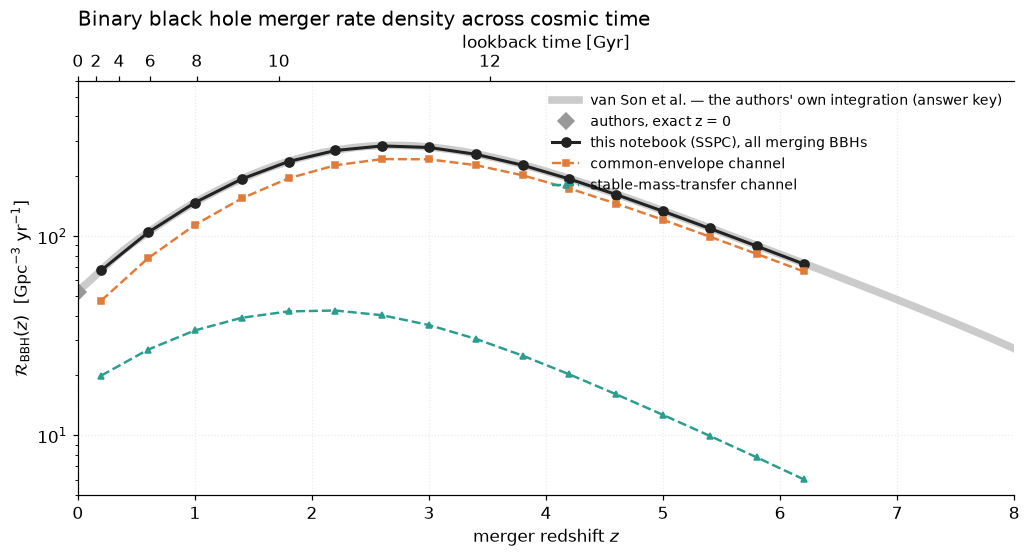

peak at z = 2.6: 285 Gpc^-3 yr^-1, i.e. 4.2x the z = 0.2 rate
channel share at z = 0.2: CE 70%, SMT 30%;   at z = 2.6: CE 86%, SMT 14%


In [44]:
# channel split, as in Notebook 2 Part 5: no common envelope = stable mass transfer channel
is_smt = (bbh.n_CE == 0).values
R_sspc_ce  = np.array([read_sspc_yield(z)[~is_smt].sum() for z in CONV_Z])
R_sspc_smt = np.array([read_sspc_yield(z)[is_smt].sum() for z in CONV_Z])

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(z_authors, R_authors, color=C_WRONG, lw=5, alpha=0.5, label="van Son et al. — the authors' own integration (answer key)")
ax.plot([0], [R_authors_z0], "D", color=C_WRONG, ms=7, label="authors, exact z = 0")
ax.plot(CONV_Z, R_sspc, "o-", color=CSYS, lw=2, ms=6, label="this notebook (SSPC), all merging BBHs")
ax.plot(CONV_Z, R_sspc_ce,  "s--", color=C_CE,  lw=1.6, ms=4, label="common-envelope channel")
ax.plot(CONV_Z, R_sspc_smt, "^--", color=C_SMT, lw=1.6, ms=4, label="stable-mass-transfer channel")
ax.set_yscale("log"); ax.set_ylim(5, 600); ax.set_xlim(0, 8)
ax.set_xlabel("merger redshift $z$")
ax.set_ylabel(r"$\mathcal{R}_{\rm BBH}(z)$  [Gpc$^{-3}$ yr$^{-1}$]")
ax.set_title("Binary black hole merger rate density across cosmic time", loc="left")
secax = ax.secondary_xaxis("top", functions=(lambda z: lookback_time_Myr(z) / 1e3,
                                             lambda t: redshift_at_lookback_time(t * 1e3)))
secax.set_xlabel("lookback time [Gyr]")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

i_pk = np.argmax(R_sspc)
print(f"peak at z = {CONV_Z[i_pk]:.1f}: {R_sspc[i_pk]:.0f} Gpc^-3 yr^-1, i.e. {R_sspc[i_pk]/R_sspc[0]:.1f}x the z = 0.2 rate")
print(f"channel share at z = 0.2: CE {100*R_sspc_ce[0]/R_sspc[0]:.0f}%, SMT {100*R_sspc_smt[0]/R_sspc[0]:.0f}%;"
      f"   at z = {CONV_Z[i_pk]:.1f}: CE {100*R_sspc_ce[i_pk]/R_sspc[i_pk]:.0f}%, SMT {100*R_sspc_smt[i_pk]/R_sspc[i_pk]:.0f}%")

### 📖 What to notice

- **We reproduce the authors to a few percent** at every redshift, with an independent code,
  having built every ingredient ourselves. The residual is the cosmology (we use Planck 2018; the
  authors' pipeline used a slightly different one), the finite redshift and metallicity grids,
  bin-averaging versus point evaluation, and the treatment of the edges of the metallicity range. That level of agreement is what "same
  physics, same $S(Z,z)$" *should* give; if you ever see a factor of 2, something is wrong.
- **The rate rises steeply with redshift** — by a factor of ~4 from $z=0.2$ to the peak — and
  the peak sits close to the star formation peak of this $\psi(z)$ ($z \approx 2.7$). That is not a
  coincidence: $\mathcal{R}(z)$ is the star formation history, delayed by the delay times (which
  pushes the peak to *lower* $z$) and reweighted by the metallicity evolution (more metal-poor star
  formation at high $z$ → higher $\eta$, which pushes it back *up*).
- **Extra: The two channels evolve differently.** Their ratio changes with redshift because they have
  different delay-time and metallicity dependences. Look at the printed percentages and compare
  with the Notebook 2 census: which channel gains importance at high redshift, and can you explain
  it from what you learned about their separations and delay times? (from the Double Compact Objects file)
- Extra:  The **shape** of $\mathcal{R}(z)$ at $z \lesssim 1$ is what LVK measures as the "redshift
  evolution" parameter $\kappa$ ($\mathcal{R} \propto (1+z)^\kappa$). We will compare in Part 5.

## 4.3 Headline plot 2: the primary mass distribution at $z \approx 0.2$

Now the plot the whole field cares about. At the $z = 0.2$ bin, each system's yield tells us how
much it contributes to the local merger rate, so a histogram of $m_1$ weighted by yield gives
$\mathrm{d}\mathcal{R}/\mathrm{d}m_1$ — the merger rate density *per unit primary mass*, in
Gpc$^{-3}$ yr$^{-1}$ M$_\odot^{-1}$. This is directly what LVK's population analyses infer.

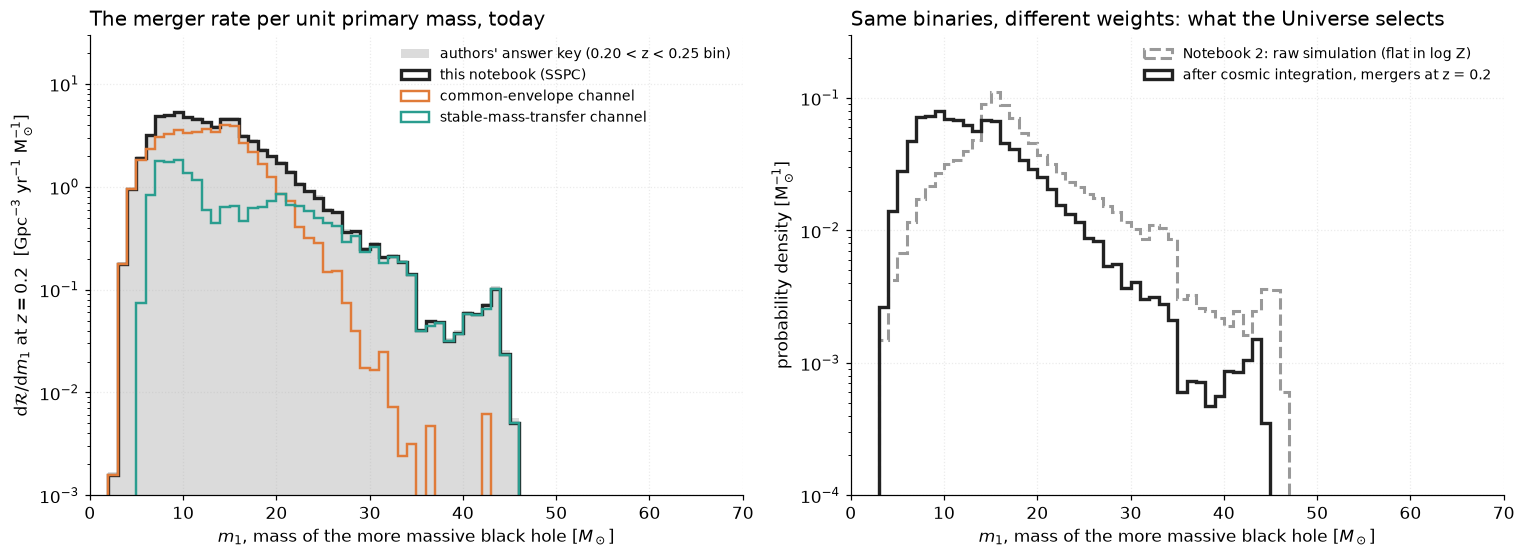

raw simulation (Notebook 2)   : median m1 =  16.6 Msun,  fraction with m1 > 30 Msun =  7.9%
cosmic-integrated, z = 0.2    : median m1 =  12.7 Msun,  fraction with m1 > 30 Msun =  2.3%


In [45]:
yield_z02 = read_sspc_yield(0.2)
m1_bins = np.arange(0, 70.5, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# --- left: absolute, with the answer key and the channel split ---------------------------------
ax = axes[0]
ax.hist(bbh.m1, bins=m1_bins, weights=rate_authors_z02, histtype="stepfilled", color=C_WRONG, alpha=0.35,
        label="authors' answer key (0.20 < z < 0.25 bin)")
ax.hist(bbh.m1, bins=m1_bins, weights=yield_z02, histtype="step", lw=2.2, color=CSYS, label="this notebook (SSPC)")
ax.hist(bbh.m1[~is_smt], bins=m1_bins, weights=yield_z02[~is_smt], histtype="step", lw=1.6, color=C_CE, label="common-envelope channel")
ax.hist(bbh.m1[is_smt],  bins=m1_bins, weights=yield_z02[is_smt],  histtype="step", lw=1.6, color=C_SMT, label="stable-mass-transfer channel")
ax.set_yscale("log"); ax.set_ylim(1e-3, 30)
ax.set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m_1$ at $z=0.2$  [Gpc$^{-3}$ yr$^{-1}$ M$_\odot^{-1}$]")
ax.set_title("The merger rate per unit primary mass, today", loc="left")
ax.legend(fontsize=9)

# --- right: shape only, compared with the RAW population of Notebook 2 -----------------------
ax = axes[1]
ax.hist(bbh.m1, bins=m1_bins, weights=bbh.w, density=True, histtype="step", lw=2, color=C_WRONG, ls="--",
        label="Notebook 2: raw simulation (flat in log Z)")
ax.hist(bbh.m1, bins=m1_bins, weights=yield_z02, density=True, histtype="step", lw=2.2, color=CSYS,
        label="after cosmic integration, mergers at z = 0.2")
ax.set_yscale("log"); ax.set_ylim(1e-4, 0.3)
ax.set_ylabel("probability density [M$_\\odot^{-1}$]")
ax.set_title("Same binaries, different weights: what the Universe selects", loc="left")
ax.legend(fontsize=9)

for ax in axes:
    ax.set_xlabel(r"$m_1$, mass of the more massive black hole [$M_\odot$]")
    ax.set_xlim(0, 70)
plt.tight_layout(); plt.show()


def weighted_quantile(x, w, q):
    o = np.argsort(x); cw = np.cumsum(w[o]); return x[o][np.searchsorted(cw, q * cw[-1])]


for label, wts in [("raw simulation (Notebook 2)", bbh.w.values), ("cosmic-integrated, z = 0.2", yield_z02)]:
    print(f"{label:30s}: median m1 = {weighted_quantile(bbh.m1.values, wts, 0.5):5.1f} Msun,  "
          f"fraction with m1 > 30 Msun = {100 * wts[bbh.m1.values > 30].sum() / wts.sum():4.1f}%")

### 📖 What to notice

- **Left panel: the answer key again agrees**, bin by bin, including the features you learned
  to read in Notebook 2: the lower edge set by the remnant-mass prescription, the broad bulk from
  ~8 to ~35 $M_\odot$, the pile-up just below the pair-instability gap at ~45 $M_\odot$, and the
  cliff above it.
- **The channels occupy different masses.** Compare orange and teal: which channel dominates
  the massive end, and which the low-mass end? This is the kind of prediction that
  *observations of the mass distribution* can test, which is the whole point of GROWL.
- **Right panel: cosmic integration changes the shape, not just the normalisation.** The raw
  simulation gives equal say to every metallicity; the Universe at $z \lesssim 2$ formed most of
  its stars at relatively high metallicity, where black holes are lighter. So after cosmic
  integration the distribution shifts to **lower** masses and the high-mass fraction drops (see the
  printed numbers). If you had shown the raw Notebook 2 histogram to an observer as "our
  prediction", you would have over-predicted heavy black holes — this is the caveat from Notebook
  2 §0.3 made quantitative.

## Extra: 4.4 Before you compare with observations: what could be wrong with this prediction?

You have a prediction with **zero error bars**. That is not because it is certain — it is because
we have not yet propagated any uncertainty. Before Part 5 puts it next to real data, make a list
of what could shift it, and how. Our list, roughly in order of importance:

| Source | Typical effect on $\mathcal{R}(z=0.2)$ | Where in this notebook |
|---|---|---|
| Low-metallicity tail of $\mathrm{d}P/\mathrm{d}Z$ | at least factor of several | §2.3 |
| Binary-evolution physics (common envelope, winds, kicks, mass-transfer stability) | at least factor of several; also moves features in $m_1$ | Notebooks 1–2; not varied here |
| $\psi(z)$ normalisation and shape |  at least tens of percent | §2.2 |
| IMF, binary fraction, mass-ratio distribution ($M_{\rm rep}$) | at least tens of percent | §1.3 |
| Cosmology, grids, edge treatment | at most few percent | §4.1 |
| Statistical noise from 1.6 million sampled systems | small for the total, visible in sparse mass bins | Notebook 2 §1.4 |

Keep this table in mind when you look at the observations. A model that lands within a factor
of two of the measured rate is *consistent*; a model that lands within 10% is *extremely lucky*. For the GROWL Catalog we will explore some of these uncertainties to see if simulations match obesrvations for a range of uncertainties (or never). This way we can also use Binary Black Hole observations to infer the IMF, star formation history etc.

<a id="part5"></a>
# Part 5 — Comparing with LVK observations (GWTC-5.0)

## 5.1 What LVK actually measures — and why it is comparable to what we computed

The LIGO–Virgo–KAGRA collaboration does not observe $\mathcal{R}(z)$ or $p(m_1)$ directly. It
observes a few hundred individual mergers, each with uncertain masses and distances, through
detectors that are far more sensitive to nearby, heavy systems than to distant, light ones. Turning
that into a statement about the *underlying population* is a
[hierarchical Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_hierarchical_modeling)
problem: assume a family of population shapes, and find which members of the family are consistent
with the catalogue *once the detector's selection function has been taken into account*.

Two consequences matter for us:

1. **The result is a set of posterior draws, not a curve.** For each quantity LVK publishes
   thousands of possible $\mathcal{R}(z)$ (or $p(m_1)$) curves, each equally consistent with the
   data. Their spread is the measurement uncertainty; the plots below show the median and the
   5–95% band.
2. **Selection effects have been removed.** What is published is the *intrinsic*, source-frame,
   comoving rate — exactly the quantity our cosmic integration produces. So we can overplot the
   two without any further correction. (Whether that is also true of the *masses* is subtler; see
   §5.4.)

The results also depend on which *family of shapes* was assumed. We show two of the models from
the GWTC-5.0 population paper:

| Model | What it assumes | Good for |
|---|---|---|
| **Default BBH** | A parametric form: broken power law with two Gaussian peaks in $m_1$, and $\mathcal{R}(z) \propto (1+z)^{\kappa_z}$ | Tight constraints, clear parameters ($\kappa_z$!) — *if* the form is right |
| **PixelPop** | Non-parametric: the rate in each of many "pixels" in $(m_1, m_2)$ or $z$ is a free parameter, with a smoothness prior | Letting the data speak; wider bands |

Where the two disagree, the difference is a *modelling* uncertainty on the observational side —
which is worth remembering when you compare a simulation to "the observations".

**Where the numbers come from.** The full GWTC-5.0 data release
([Zenodo 10.5281/zenodo.20292639](https://doi.org/10.5281/zenodo.20292639)) is 42 GB!!!. **We therefore extracted for you just the two quantities we need into a 7 MB file**, which is provided in this GROWL directory one level higher at `lvk_observations/GWTC-5_extract/gwtc5_bbh_rate_and_mass.h5`, you might have to download this from Github if you dont have it yet (ie you didnt clone the entire directory). These files contain a script that follows the paper's own figure notebooks; the README in that folder lists
exactly which release files were used. If you use these numbers, cite the GWTC-5.0 population
paper and the Zenodo DOI, not this repository.

In [46]:
LVK_FILE = "../lvk_observations/GWTC-5_extract/gwtc5_bbh_rate_and_mass.h5"

lvk = {}
with h5py.File(LVK_FILE, "r") as f:
    print("source:", f.attrs["source"])
    Z_PE_1ST, Z_PE_99TH = f.attrs["pe_redshift_1st_99th_percentile"]
    M1_PE_1ST, M1_PE_99TH = f.attrs["pe_mass_1_source_1st_99th_percentile"]
    for model in ["default_bbh", "pixelpop"]:
        for key in ["rate_vs_redshift", "dR_dm1_z0.2"]:
            g = f[f"{model}/{key}"]
            lvk[(model, key)] = {"x": g["positions"][()], "q05": g["quantiles"][0], "q50": g["quantiles"][1],
                                 "q95": g["quantiles"][2], "unit": g.attrs["unit"], "n": g.attrs["n_draws_total"]}
    lvk_lamb = f["default_bbh/lamb"][()]

for (model, key), d in lvk.items():
    print(f"{model:12s} {key:16s}: {d['n']:5d} posterior draws on a grid of {len(d['x'])} points, unit {d['unit']}")
print(f"\nthe events constrain the fits between z = {Z_PE_1ST:.2f} and {Z_PE_99TH:.2f}, and m1 = {M1_PE_1ST:.1f} and {M1_PE_99TH:.0f} Msun"
      " (1st/99th percentiles of the events' posterior samples)")

i02 = np.argmin(np.abs(lvk[("default_bbh", "rate_vs_redshift")]["x"] - 0.2))
d = lvk[("default_bbh", "rate_vs_redshift")]
print(f"\nLVK Default BBH  R(z = 0.2) = {d['q50'][i02]:.1f}  (90% interval {d['q05'][i02]:.1f} - {d['q95'][i02]:.1f})  Gpc^-3 yr^-1")
print(f"LVK kappa_z (R ~ (1+z)^kappa): median {np.median(lvk_lamb):.2f}, 90% interval {np.quantile(lvk_lamb, 0.05):.2f} - {np.quantile(lvk_lamb, 0.95):.2f}")
print(f"this notebook  R(z = 0.2) = {R_sspc[0]:.1f}   ->  simulation / observation = {R_sspc[0] / d['q50'][i02]:.2f}")

source: GWTC-5.0: Population Properties of Merging Compact Binaries, https://doi.org/10.5281/zenodo.20292639
default_bbh  rate_vs_redshift:  8200 posterior draws on a grid of 2500 points, unit Gpc^-3 yr^-1
default_bbh  dR_dm1_z0.2     :  8200 posterior draws on a grid of 1000 points, unit Gpc^-3 yr^-1 Msun^-1
pixelpop     rate_vs_redshift:  4000 posterior draws on a grid of 101 points, unit Gpc^-3 yr^-1
pixelpop     dR_dm1_z0.2     :  4000 posterior draws on a grid of 101 points, unit Gpc^-3 yr^-1 Msun^-1

the events constrain the fits between z = 0.06 and 1.39, and m1 = 8.3 and 112 Msun (1st/99th percentiles of the events' posterior samples)

LVK Default BBH  R(z = 0.2) = 30.4  (90% interval 25.0 - 36.8)  Gpc^-3 yr^-1
LVK kappa_z (R ~ (1+z)^kappa): median 2.54, 90% interval 1.84 - 3.23
this notebook  R(z = 0.2) = 67.5   ->  simulation / observation = 2.22


## 5.2 The merger rate density: simulation vs. observation

We plot only $z < 1.5$: that is where the detectors have seen anything. Beyond the hatched line
($z \approx 1.4$, the 99th percentile of all event redshifts) the LVK curves are pure
extrapolation of the assumed shape, and should not be compared with anything.

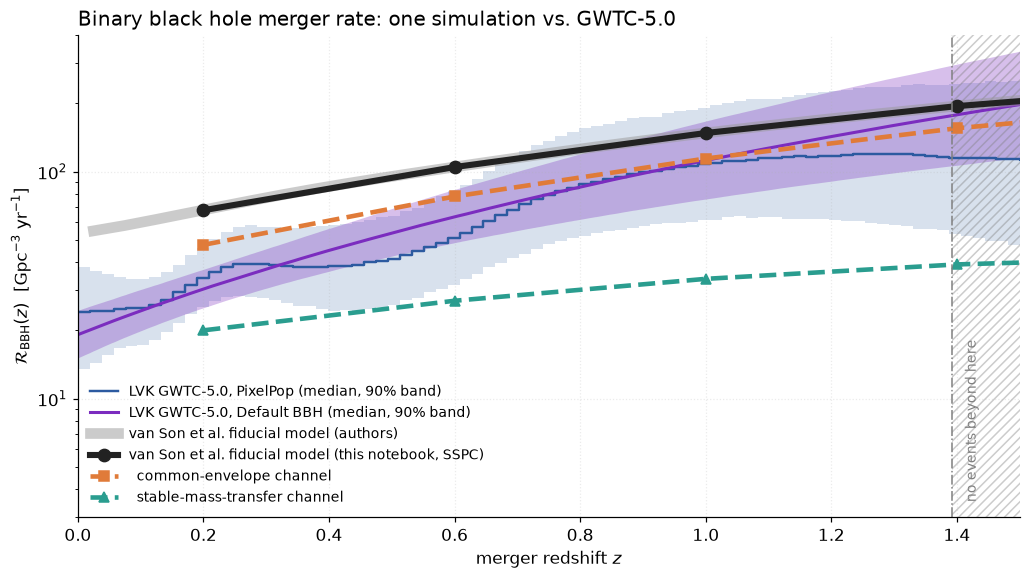

simulation: R(z=0.2) = 68 Gpc^-3 yr^-1, and R ~ (1+z)^1.5 at z < 1
LVK       : R(z=0.2) = 30 (90%: 25-37), kappa_z = 2.5 (90%: 1.8-3.2)


In [47]:
C_LVK, C_PP = C_OBS, "#2C5AA0"

fig, ax = plt.subplots(figsize=(9.5, 5.4))

# --- LVK ----------------------------------------------------------------------------------
d = lvk[("pixelpop", "rate_vs_redshift")]
ax.fill_between(d["x"], d["q05"], d["q95"], step="pre", color=C_PP, alpha=0.18, lw=0)
ax.step(d["x"], d["q50"], color=C_PP, lw=1.6, label="LVK GWTC-5.0, PixelPop (median, 90% band)")
d = lvk[("default_bbh", "rate_vs_redshift")]
ax.fill_between(d["x"], d["q05"], d["q95"], color=C_LVK, alpha=0.3, lw=0)
ax.plot(d["x"], d["q50"], color=C_LVK, lw=2, label="LVK GWTC-5.0, Default BBH (median, 90% band)")

# --- simulation ---------------------------------------------------------------------------
ax.plot(z_authors, R_authors, color=C_WRONG, lw=7, alpha=0.5, label="van Son et al. fiducial model (authors)")
ax.plot(CONV_Z, R_sspc, "o-", color=CSYS, lw=4, ms=8, label="van Son et al. fiducial model (this notebook, SSPC)")
ax.plot(CONV_Z, R_sspc_ce,  "s--", color=C_CE,  lw=3, ms=6, label="  common-envelope channel")
ax.plot(CONV_Z, R_sspc_smt, "^--", color=C_SMT, lw=3, ms=6, label="  stable-mass-transfer channel")

# --- where the data run out ---------------------------------------------------------------
ax.axvspan(Z_PE_99TH, 2, facecolor="none", edgecolor="grey", hatch="////", alpha=0.4, lw=0)
ax.axvline(Z_PE_99TH, color="grey", ls="-.", lw=1)
ax.text(Z_PE_99TH + 0.02, 3.5, "no events beyond here", rotation=90, va="bottom", fontsize=9, color="grey")

ax.set_yscale("log"); ax.set_xlim(0, 1.5)
ax.set_xlabel("merger redshift $z$")
ax.set_ylabel(r"$\mathcal{R}_{\rm BBH}(z)$  [Gpc$^{-3}$ yr$^{-1}$]")
ax.set_title("Binary black hole merger rate: one simulation vs. GWTC-5.0", loc="left")
ax.set_ylim(3, 400)
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

# the shape: fit R ~ (1+z)^kappa to our points at z <= 1, to compare with LVK's kappa_z
sel = CONV_Z <= 1.0
kappa_sim = np.polyfit(np.log1p(CONV_Z[sel]), np.log(R_sspc[sel]), 1)[0]
print(f"simulation: R(z=0.2) = {R_sspc[0]:.0f} Gpc^-3 yr^-1, and R ~ (1+z)^{kappa_sim:.1f} at z < 1")
print(f"LVK       : R(z=0.2) = {lvk[('default_bbh','rate_vs_redshift')]['q50'][i02]:.0f} (90%: "
      f"{lvk[('default_bbh','rate_vs_redshift')]['q05'][i02]:.0f}-{lvk[('default_bbh','rate_vs_redshift')]['q95'][i02]:.0f}), "
      f"kappa_z = {np.median(lvk_lamb):.1f} (90%: {np.quantile(lvk_lamb, 0.05):.1f}-{np.quantile(lvk_lamb, 0.95):.1f})")

### 📖 What to notice

- **The normalisation is off by about a factor of two.** The fiducial model predicts roughly
  twice as many local mergers as LVK observe. Before you conclude the model is wrong, look at the
  table in §4.4: a factor of two is *within* the uncertainty of the metallicity-specific star
  formation history alone, and comfortably within the binary-physics uncertainties. van Son et al.
  (2022) themselves note that their fiducial rate is on the high side. This is the normal state
  of affairs for a population synthesis model: the normalisation is the *least* diagnostic thing
  about it.
- **The shape is the more interesting test.** LVK measure how fast the rate rises,
  $\kappa_z$, and it is a clean, IMF-independent, $f_{\rm bin}$-independent number. The
  observed rise ($\kappa_z \approx 2.5$) is **steeper** than the model's ($\approx 1.5$ at
  $z < 1$): the model starts a factor of two too high and the two curves cross near $z \approx 1$.
  So the disagreement is not a constant offset — it is specifically an excess of *local*
  mergers, i.e. too many systems merging long after cosmic noon. Which ingredient controls that?
  (Think about delay times, and about the metallicity of star formation at $z < 1$.) A model that
  got the normalisation right by tuning the common-envelope efficiency but kept the wrong
  $\kappa_z$ would be in worse shape than this one.
- **The two LVK models agree where there are data, and diverge where there are not.** That is
  what a good non-parametric model should do. Never compare to the extrapolated part.

## 5.3 The primary-mass distribution at $z \approx 0.2$

Same exercise for the plot that carries the most information about binary physics. The LVK
curves are $\mathrm{d}\mathcal{R}/\mathrm{d}m_1$ at $z = 0.2$ (the release tabulates the $z=0$
distribution; we scaled each posterior draw by its own $(1+0.2)^{\kappa_z}$, as the paper's own
figure script does). The simulation is the yield-weighted histogram from §4.3, divided by the bin
width so that both are densities. Log–log axes, as in the paper, because both the masses and the
rates span decades.

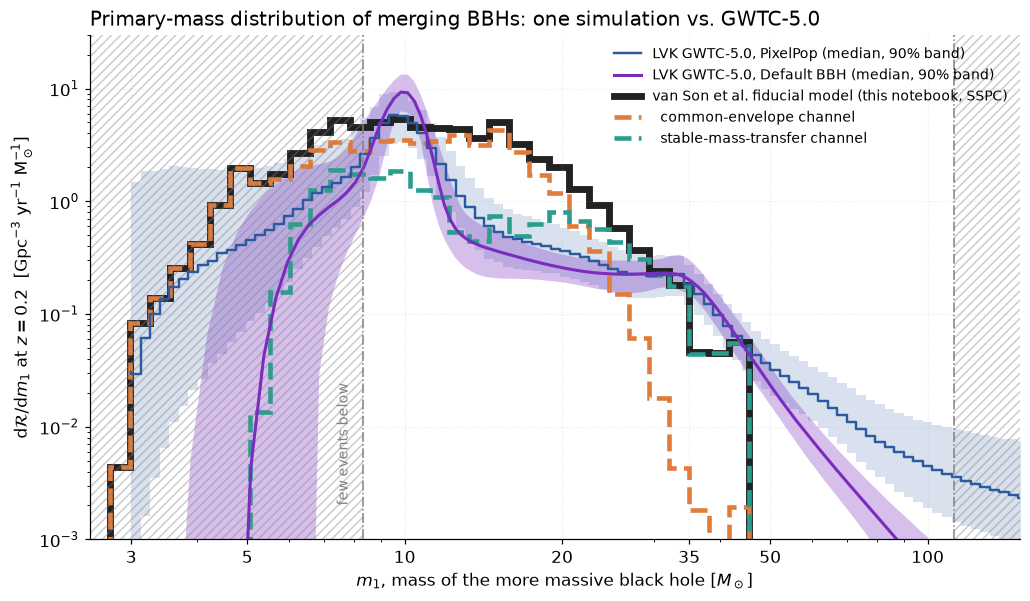

   m1 range [Msun]   simulation   LVK median    ratio     [Gpc^-3 yr^-1]
       5 - 10             20.21        10.68     1.89
      10 - 20             36.66        10.80     3.39
      20 - 35              9.00         3.34     2.70
      35 - 50              0.53         1.26     0.42
      50 - 100             0.00         0.22     0.00


In [49]:
m1_bins_log = np.logspace(np.log10(2.5), np.log10(120), 45)
h_sim, _ = np.histogram(bbh.m1, bins=m1_bins_log, weights=yield_z02)
dRdm1_sim = h_sim / np.diff(m1_bins_log)
h_ce, _ = np.histogram(bbh.m1[~is_smt], bins=m1_bins_log, weights=yield_z02[~is_smt])
h_smt, _ = np.histogram(bbh.m1[is_smt], bins=m1_bins_log, weights=yield_z02[is_smt])

fig, ax = plt.subplots(figsize=(9.5, 5.6))

d = lvk[("pixelpop", "dR_dm1_z0.2")]
ax.fill_between(d["x"], d["q05"], d["q95"], step="pre", color=C_PP, alpha=0.18, lw=0)
ax.step(d["x"], d["q50"], color=C_PP, lw=1.6, label="LVK GWTC-5.0, PixelPop (median, 90% band)")
d = lvk[("default_bbh", "dR_dm1_z0.2")]
ax.fill_between(d["x"], d["q05"], d["q95"], color=C_LVK, alpha=0.3, lw=0)
ax.plot(d["x"], d["q50"], color=C_LVK, lw=2, label="LVK GWTC-5.0, Default BBH (median, 90% band)")

ax.stairs(dRdm1_sim, m1_bins_log, color=CSYS, lw=4.5, label="van Son et al. fiducial model (this notebook, SSPC)")
ax.stairs(h_ce / np.diff(m1_bins_log), m1_bins_log, color=C_CE, lw=3, ls="--", label="  common-envelope channel")
ax.stairs(h_smt / np.diff(m1_bins_log), m1_bins_log, color=C_SMT, lw=3, ls="--", label="  stable-mass-transfer channel")

for lo, hi in [(2, M1_PE_1ST), (M1_PE_99TH, 200)]:
    ax.axvspan(lo, hi, facecolor="none", edgecolor="grey", hatch="////", alpha=0.4, lw=0)
ax.axvline(M1_PE_1ST, color="grey", ls="-.", lw=1); ax.axvline(M1_PE_99TH, color="grey", ls="-.", lw=1)
ax.text(M1_PE_1ST * 0.95, 2e-3, "few events below", rotation=90, ha="right", va="bottom", fontsize=9, color="grey")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(2.5, 150); ax.set_ylim(1e-3, 30)
ax.set_xticks([3, 5, 10, 20, 35, 50, 100]); ax.set_xticklabels(["3", "5", "10", "20", "35", "50", "100"])
ax.set_xlabel(r"$m_1$, mass of the more massive black hole [$M_\odot$]")
ax.set_ylabel(r"$\mathrm{d}\mathcal{R}/\mathrm{d}m_1$ at $z = 0.2$  [Gpc$^{-3}$ yr$^{-1}$ M$_\odot^{-1}$]")
ax.set_title("Primary-mass distribution of merging BBHs: one simulation vs. GWTC-5.0", loc="left")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

# integrated rates in a few mass ranges, simulation vs LVK median (Default BBH)
d = lvk[("default_bbh", "dR_dm1_z0.2")]
print(f"{'m1 range [Msun]':>18s} {'simulation':>12s} {'LVK median':>12s} {'ratio':>8s}     [Gpc^-3 yr^-1]")
for lo, hi in [(5, 10), (10, 20), (20, 35), (35, 50), (50, 100)]:
    r_sim = yield_z02[(bbh.m1.values >= lo) & (bbh.m1.values < hi)].sum()
    m = (d["x"] >= lo) & (d["x"] < hi)
    r_lvk = np.trapezoid(d["q50"][m], d["x"][m])
    print(f"{lo:8.0f} - {hi:<7.0f} {r_sim:12.2f} {r_lvk:12.2f} {r_sim / r_lvk:8.2f}")

### 📖 What to notice

Read this plot in three mass ranges, because the story is different in each:

- **Below ~8 $M_\odot$ (hatched: few events): surprisingly good.** The simulation tracks the
  PixelPop median closely; the Default BBH curve falls off a cliff here only because that model
  *assumes* a sharp minimum mass. Do not over-interpret either — LVK have almost no events this
  low mass, so the observed curve is largely prior.
- **The ~10 $M_\odot$ peak and the 10–30 $M_\odot$ range: this is where the factor of two
  lives.** Both LVK models show a sharp peak near 10 $M_\odot$ followed by a steep drop; the
  simulation instead has a broad plateau from ~8 to ~25 $M_\odot$, producing about **three times
  too many** 10–35 $M_\odot$ black holes (see the printed ratios). Look at the channel curves:
  the plateau is the common-envelope channel. That is a specific, testable statement about the
  physics — and the reason people argue about common-envelope efficiency.
- **The famous ~35 $M_\odot$ peak, and above**: LVK see a clear bump at 35 $M_\odot$ (both
  models) — the model has *nothing* there. Its pile-up sits at 40–45 $M_\odot$, just below the
  pair-instability gap, and it produces **nothing above ~47 $M_\odot$**, while the observed
  distribution continues (with growing uncertainty) past 100 $M_\odot$. Where the 35 $M_\odot$
  feature comes from is one of the open questions in the field, and where the > 50 $M_\odot$
  black holes come from is another — isolated binary evolution with this physics does not make
  them. That is not a failure of the notebook; it is the reason GROWL exists.

## 5.4 Two things to be honest about before you show this plot to anyone

1. **Source-frame masses.** LVK measure redshifted (detector-frame) masses and convert to
   source-frame using each event's inferred distance. The population results above are in the
   source frame, so the comparison is fair — but the conversion is part of the inference, and the
   $m_1$ of individual events carries 10–30% uncertainties that the population model absorbs into
   its posterior bands.
2. **The bands are not error bars on "the truth".** They are what a *particular family of
   shapes* can accommodate. The Default BBH model *assumes* a peak-plus-power-law form, so its
   band will always show a peak somewhere; PixelPop does not, which is why its band is wider and
   bumpier. When a simulation lies outside the Default band but inside PixelPop's, the disagreement
   is with the parametric assumption, not necessarily with the data. Use both.

> ### ✍️ Task 3 — write the comparison up
>
> In one paragraph, as you would in a paper's discussion section, state (i) where this model
> agrees with GWTC-5.0, (ii) where it disagrees, (iii) which *single* ingredient from the §4.4
> table you would change first to reduce the disagreement, and (iv) which observable would let
> you tell whether that change was the right one. Aim for five sentences, no hedging words you
> cannot justify.

<a id="exercises"></a>
# Part 6 — Your turn 🎓

**Pick whichever ones appeal to you — nobody is expected to do all of them.** Exercise 1 is the
warm-up; Exercise 6 is the one that will save you from a wrong paper one day. Bring whatever you
make, and your questions, to the onboarding session.

### Exercise 1 — Neutron stars (warm-up, required)

Everything in Parts 3–4 was done for binary black holes. Repeat it for **binary neutron stars**
(`dco.is_BNS & (dco.merges == 1)`) and for **black hole–neutron star** binaries: build the `eta`
column, write a second input table into the same SSPC file under `input_data/bns` (and `/bhns`),
add a convolution instruction for each, and get $\mathcal{R}(z = 0.2)$. The observed local rates
are roughly $10$–$1700$ Gpc$^{-3}$ yr$^{-1}$ for BNS and $8$–$140$ for BHNS (GWTC-3; check the
GWTC-5.0 paper for the current numbers). Is this simulation consistent with them?

> Hint: the authors' answer key covers these too — `DCOmask` includes all merging DCOs, so you
> can check yourself the same way we did in §4.1.

In [ ]:
# --- Exercise 1 ------------------------------------------------------------------
# bns = dco[dco.is_BNS & (dco.merges == 1)].copy()
# bns["z_bin"] = ...
# bns["eta"]   = ...
# YOUR CODE HERE

### Exercise 2 — The merger rate is linear in the things you cannot measure

Change the binary fraction in §1.3 from 0.7 to 1.0 and to 0.5, and recompute $M_{\rm rep}$. By what
factor does *every* rate in this notebook change? (You do **not** need to rerun SSPC — think about
where $M_{\rm rep}$ enters.) Now do the same for the IMF upper mass limit (150 → 300 $M_\odot$)
and the lower limit of the simulated primary mass (5 → 8 $M_\odot$, keeping the IMF fixed). Rank
the three by how much they matter, and write one sentence on which of them an observer could
actually constrain.

### Extra: Exercise 3 — Do heavier black holes merge earlier?

Plot the yield-weighted $m_1$ distribution at $z = 0.2$ and at $z = 2.6$ (the peak) on the same
axes, normalised to unit area. Does the distribution shift? In which direction, and why — think
about which metallicities dominate the star formation at each birth redshift (§2.3) and what
metallicity does to black hole masses (Notebook 2, Part 6). Then do the same for the chirp mass.

### Extra: Exercise 4 — Where did today's mergers come from, really?

In §2.4 we found that, *before* applying any star formation history, ~8% of the binaries merging
at $z = 0.2$ were born at $z > 1$. Redo that plot with the SSPC yields as weights instead of
`eta` (you will need the birth redshift of each system for a merger at $z = 0.2$, which you can
compute exactly as in §2.4). What fraction is it now, and why did it change? Then split it by
channel.

### Exercise 5 — Swap the Universe

Replace the van Son et al. (2023) $\psi(z)$ parameters with the Madau & Dickinson (2014) ones
($a = 0.015,\ b = 2.7,\ c = 2.9,\ d = 5.6$; already plotted in §2.2), rebuild `sfr_dict`, rerun
SSPC into a *different* output file, and overplot $\mathcal{R}(z)$. Then keep $\psi$ fixed and
change only the metallicity distribution: try $\mu_z = -0.15$ (faster metallicity evolution) or
$\alpha = 0$ (no skew). Which single parameter moves $\mathcal{R}(z = 0.2)$ the most? Compare with
the table in §4.4.

### Extra: Exercise 6 — Make the mistake on purpose 

Build an input table whose yield column is `bbh.w / M_SIM` instead of `bbh.eta` — i.e. divide by the
*total* simulated mass, as one very naturally would — run SSPC on it, and compare
$\mathcal{R}(z = 0.2)$ with the correct value. By what factor is it off? Now change `N_Z_BINS` from
50 to 200 (rebuild `LOG_Z_EDGES`, `mass_per_bin`, `sfr_dict`) and run both versions again. Which
one moved? Write down, in one paragraph you could send to a collaborator, *why* one is right and
the other is wrong. This is the single most common cosmic-integration bug, and now you can
recognise it.

### Super Extra (probably leave for now): Exercise 7 — Detection rates (stretch, open-ended) 🌌

Everything here is an *intrinsic* rate: what happens in the Universe. What LIGO *detects* also
depends on the detector's sensitivity, which favours nearby, heavy systems. Read §2.4 of
[Neijssel et al. (2019)](https://arxiv.org/abs/1906.08136) on selection effects, and sketch (in
words or code) how you would turn $\mathrm{d}\mathcal{R}/\mathrm{d}m_1$ at each redshift into a
*detected* mass distribution. Which ingredient are you missing? (SSPC supports a
`post_convolution_function` hook for exactly this kind of per-system weighting.)

<a id="glossary"></a>
# Glossary

| Term | Meaning |
|---|---|
| **Binary fraction** $f_{\rm bin}$ | Fraction of stars (here: massive stars) born in binaries. Enters $M_{\rm rep}$; 0.7 in this work. |
| **Comoving volume** | Volume measured in coordinates that expand with the Universe, so that a fixed comoving box always contains the same galaxies. Rates are quoted per comoving Gpc³. |
| **Convolution** | Sliding one function over another and integrating. Here: the delay-time distribution over the star formation history. |
| **Cosmic integration** | Turning a simulated population plus $S(Z,z)$ and delay times into a merger rate density as a function of redshift. |
| **Cosmic noon** | The epoch of peak cosmic star formation, $z \approx 2$–3, about 10–11 Gyr ago. |
| **Delay time** | Time from the birth of the two stars to the merger of the compact objects (`Time + Coalescence_Time`). |
| **Formation efficiency** $\eta$ | Number of (merging) double compact objects formed per solar mass of star formation; units M$_\odot^{-1}$. Depends strongly on metallicity. |
| **IMF** (initial mass function) | The distribution of birth masses of stars; steeply falling, so most stars — and most stellar mass — are light. We use Kroupa (2001). |
| **Lookback time** | How long ago light from redshift $z$ was emitted; the cosmic clock that converts delay times into birth redshifts. |
| **Mass–metallicity relation** | Empirical relation between a galaxy's stellar mass and the metallicity of its gas; one of the ingredients of $\mathrm{d}P/\mathrm{d}Z(Z \mid z)$. |
| $M_{\rm rep}$ | Star-forming mass represented by one simulated binary, including the unsimulated light stars and single stars. ~100 $M_\odot$ here. |
| $M_{\rm sim}$ | $N_{\rm binaries} \times M_{\rm rep}$: the total star-forming mass the simulation stands for. ~10⁹ $M_\odot$ here. |
| **Merger rate density** $\mathcal{R}(z)$ | Mergers per comoving Gpc³ per source-frame year at redshift $z$. |
| **Metallicity distribution** $\mathrm{d}P/\mathrm{d}Z(Z \mid z)$ | Fraction of newly formed stellar mass at each metallicity, at each redshift. Modelled here as a skewed log-normal (van Son et al. 2023). |
| **Metallicity-specific SFRD** $S(Z,z)$ | $\psi(z) \times \mathrm{d}P/\mathrm{d}Z(Z \mid z)$: star formation rate density split by metallicity. The "Universe half" of cosmic integration. |
| **normalized_yield** | SSPC's name for the per-system number of events per solar mass formed *in that system's metallicity bin* — our `eta`. |
| **Planck 2018** | The cosmological parameters (expansion rate, matter density, ...) we use to convert redshift to time and volume. |
| **Redshift** $z$ | Fractional stretching of light by cosmic expansion; a proxy for distance and cosmic time. |
| **SFRD** $\psi(z)$ | Cosmic star formation rate density: stellar mass formed per year per comoving volume at redshift $z$. |
| **Source frame** | Time measured by a clock at the merger, not by us (cosmic expansion stretches time by $1+z$). |
| **SSPC** | Synthetic Stellar Population Convolve — the code that performs the cosmic integration in this notebook. |
| **Yield** (SSPC output) | Each system's contribution to $\mathcal{R}$ at a given redshift, in Gpc$^{-3}$ yr$^{-1}$. |

# ✅ Summary — what you did

1. Understood why the raw population of Notebook 2 is **not** a prediction, and wrote down the
   one equation that turns it into one.
2. Derived and computed the **formation efficiency**: how much star-forming mass one simulated
   binary represents ($M_{\rm rep} \approx 100$ $M_\odot$, including the ~73% of stellar mass in
   stars too light to simulate, and the single stars), and hence how many merging binary black
   holes form per solar mass of star formation — as a function of metallicity, and *without* the
   trap of dividing by the wrong mass.
3. Learned the ingredients of the **metallicity-specific cosmic star formation history**
   $S(Z,z)$ — $\psi(z)$ and $\mathrm{d}P/\mathrm{d}Z(Z \mid z)$ — how each is observed, and how
   uncertain each is; and how **delay times** connect a merger redshift to a birth redshift.
4. Ran a real cosmic-integration code, **SSPC**, from scratch: built its input table, its
   $S(Z,z)$ grid and its configuration, and read its output.
5. Made the two headline plots — $\mathcal{R}_{\rm BBH}(z)$ and $\mathrm{d}\mathcal{R}/\mathrm{d}m_1$
   at $z = 0.2$ — and **reproduced the authors' own published integration to 0.3%** at
   $z = 0.2$, using the answer key hidden in the data file.
6. Saw that cosmic integration **changes the shape** of the mass distribution, not just its
   normalisation, and listed what could still be wrong with the prediction before comparing it
   with observations.
7. Put the prediction next to the **GWTC-5.0** population measurements — $\mathcal{R}(z)$ and
   $\mathrm{d}\mathcal{R}/\mathrm{d}m_1$ at $z=0.2$, parametric and non-parametric — and learned
   to read the comparison: normalisation (a factor of two, within model uncertainties), the
   redshift slope $\kappa_z$, and the mass features the model does and does not reproduce.

# ➡️ Next steps

- You are now ready to contribute to the GROWL Catalog! We will use everything we have learned to create similar results for unique datasets, mapping the populations of binary black holes coming out of these simulations. We will investigate their properties.  **For GROWL**: every catalogue entry needs exactly what you did in Parts 1 and 3 — a formation   efficiency and a cosmic integration — for a different simulation, with different assumptions with this notebook you now have the template.

### Questions?

Cosmic integration is genuinely the hardest step in this series, and it is normal for the
bookkeeping (which mass, which bin, which redshift) to take a second pass to sink in. If any part
did not click, write down *where* it lost you — that is the most useful thing you can bring to the
meeting.

---
*GROWL onboarding notebook 3 · data: van Son et al., [Zenodo 10.5281/zenodo.7612755](https://doi.org/10.5281/zenodo.7612755),
simulated with [COMPAS](https://compas.science/) · cosmic integration with
[SSPC](https://synthetic-stellar-pop-convolve.readthedocs.io/) (D. Hendriks; GROWL fork). Please cite the authors if you reuse any of it.*